# Modeling Stage

Forecasting for both **monthly passenger traffic** and **monthly cargo traffic** for the next 36 months.

For each target, the notebook models domestic traffic, international traffic, and the combined national total.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

RANDOM_STATE = 335
TEST_MONTHS = 24
FORECAST_HORIZON = 36
CONFIDENCE_LEVEL = 0.75
CONFIDENCE_Z = 1.1503493803760083

## Select Modeling Technique

The project now includes **two monthly targets**: passenger traffic and cargo traffic. Both targets show long-term trend, yearly seasonality, and structural shocks such as the 2016 slowdown and the COVID-19 period. Because no single model is guaranteed to dominate across all six series, the notebook compares several approaches.

The candidate techniques are:
- **Seasonal naive baseline** to create a transparent benchmark.
- **Holt-Winters exponential smoothing (ETS)** to model level, trend, and seasonality directly.
- **SARIMAX** to capture autocorrelation and seasonal structure with a classical time-series model.
- **Random forest with lagged and rolling features** to test whether feature-based regression can improve on classical methods.

Main modeling assumption:
- annual seasonality matters, so a 12-month seasonal cycle is used

In [2]:
TARGET_CONFIGS = {
    'Passenger': {
        'value_col': 'passengers',
        'domestic_path': 'dataset/domestic_pass_monthly.csv',
        'international_path': 'dataset/international_pass_monthly.csv',
        'unit_label': 'passengers',
    },
    'Cargo': {
        'value_col': 'cargo',
        'domestic_path': 'dataset/domestic_cargo_monthly.csv',
        'international_path': 'dataset/international_cargo_monthly.csv',
        'unit_label': 'cargo volume',
    },
}
SERIES_ORDER = ['Domestic', 'International', 'Overall Brazil']
MODEL_END_DATE = pd.Timestamp('2025-12-01')


def load_prepared_series(path, label, target_name, value_col):
    df = pd.read_csv(path)
    first_col = df.columns[0]
    if first_col == '' or first_col.startswith('Unnamed'):
        df = df.drop(columns=first_col)
    df['year_month'] = pd.to_datetime(df['year_month'])
    df = df.sort_values('year_month').reset_index(drop=True)
    df = df[['year_month', value_col]].rename(columns={value_col: 'value'})
    df['series'] = label
    df['target'] = target_name
    return df


def engineer_features(df):
    feat = df[['year_month', 'value']].copy().sort_values('year_month').reset_index(drop=True)
    feat['month'] = feat['year_month'].dt.month
    feat['quarter'] = feat['year_month'].dt.quarter
    feat['year'] = feat['year_month'].dt.year
    feat['time_idx'] = np.arange(len(feat))
    feat['month_sin'] = np.sin(2 * np.pi * feat['month'] / 12)
    feat['month_cos'] = np.cos(2 * np.pi * feat['month'] / 12)

    for lag in [1, 3, 6, 12]:
        feat[f'lag_{lag}'] = feat['value'].shift(lag)

    for window in [3, 6, 12]:
        feat[f'roll_mean_{window}'] = feat['value'].shift(1).rolling(window).mean()

    feat['roll_std_6'] = feat['value'].shift(1).rolling(6).std()

    expanding = feat['value'].shift(1).expanding()
    feat['exp_mean'] = expanding.mean()
    feat['exp_std'] = expanding.std()
    feat['exp_min'] = expanding.min()
    feat['exp_max'] = expanding.max()

    return feat


datasets = {}
feature_sets = {}
raw_feature_columns = {}
summary_rows = []
excluded_rows = []

for target_name, config in TARGET_CONFIGS.items():
    domestic_raw = load_prepared_series(config['domestic_path'], 'Domestic', target_name, config['value_col'])
    international_raw = load_prepared_series(config['international_path'], 'International', target_name, config['value_col'])

    raw_feature_columns[target_name] = pd.read_csv(config['domestic_path']).columns.tolist()

    for series_name, raw_df in [('Domestic', domestic_raw), ('International', international_raw)]:
        dropped = raw_df[raw_df['year_month'] > MODEL_END_DATE].copy()
        if not dropped.empty:
            dropped['series'] = series_name
            dropped['target'] = target_name
            excluded_rows.append(dropped)

    domestic = domestic_raw[domestic_raw['year_month'] <= MODEL_END_DATE][['year_month', 'value']].copy()
    international = international_raw[international_raw['year_month'] <= MODEL_END_DATE][['year_month', 'value']].copy()

    overall = domestic.merge(
        international,
        on='year_month',
        how='inner',
        suffixes=('_domestic', '_international')
    )
    overall['value'] = overall['value_domestic'] + overall['value_international']
    overall = overall[['year_month', 'value']].copy()

    datasets[target_name] = {
        'Domestic': domestic,
        'International': international,
        'Overall Brazil': overall,
    }
    feature_sets[target_name] = {
        series_name: engineer_features(frame)
        for series_name, frame in datasets[target_name].items()
    }

    for series_name, frame in datasets[target_name].items():
        summary_rows.append({
            'target': target_name,
            'series': series_name,
            'start': frame['year_month'].min().date(),
            'end': frame['year_month'].max().date(),
            'rows': len(frame),
            'latest_value': frame['value'].iloc[-1],
        })

summary = pd.DataFrame(summary_rows)
excluded_summary = pd.concat(excluded_rows, ignore_index=True) if excluded_rows else pd.DataFrame()

print('Modeling inputs after cleaning:')
display(summary)

if not excluded_summary.empty:
    print('Excluded row(s) before modeling:')
    display(excluded_summary[['target', 'series', 'year_month', 'value']])

for target_name, columns in raw_feature_columns.items():
    print(f'Prepared feature columns available in the {target_name.lower()} source files:')
    display(columns)

Modeling inputs after cleaning:


,target,series,start,end,rows,latest_value
0,Passenger,Domestic,2008-01-01,2025-12-01,215,"8,729,241.00"
1,Passenger,International,2008-01-01,2025-12-01,215,"788,063.00"
2,Passenger,Overall Brazil,2008-01-01,2025-12-01,215,"9,517,304.00"
3,Cargo,Domestic,2008-01-01,2025-12-01,215,"34,188,162.00"
4,Cargo,International,2008-01-01,2025-12-01,216,"15,571,789.00"
5,Cargo,Overall Brazil,2008-01-01,2025-12-01,215,"49,759,951.00"


Excluded row(s) before modeling:


,target,series,year_month,value
0,Passenger,Domestic,2026-01-01,52.00
1,Cargo,Domestic,2026-01-01,286.00


Prepared feature columns available in the passenger source files:


['Unnamed: 0',
 'year_month',
 'passengers',
 'lag_1',
 'lag_3',
 'lag_6',
 'lag_12',
 'roll_mean_3',
 'roll_mean_6',
 'roll_mean_12',
 'roll_std_6',
 'exp_mean',
 'exp_std',
 'exp_min',
 'exp_max']

Prepared feature columns available in the cargo source files:


['Unnamed: 0',
 'year_month',
 'cargo',
 'lag_1',
 'lag_3',
 'lag_6',
 'lag_12',
 'roll_mean_3',
 'roll_mean_6',
 'roll_mean_12',
 'roll_std_6',
 'exp_mean',
 'exp_std',
 'exp_min',
 'exp_max']

## Generate Test Design

A random train/test split would break the time ordering of the problem, so the notebook uses a **chronological holdout** instead.

Validation design used here:
- the last **24 months** of each series are reserved as test data,
- all earlier months are used for training,
- the same split logic is applied to passenger and cargo data,
- each target is evaluated for domestic, international, and overall Brazil,
- the primary quality metric is **MAPE**, with **MAE** and **RMSE** added as supporting error measures,
- lagged and rolling features are recomputed from the historical series so the model never sees information from the future.

This design gives a realistic simulation of how the model would perform when forecasting unseen future months for both passenger and cargo traffic.

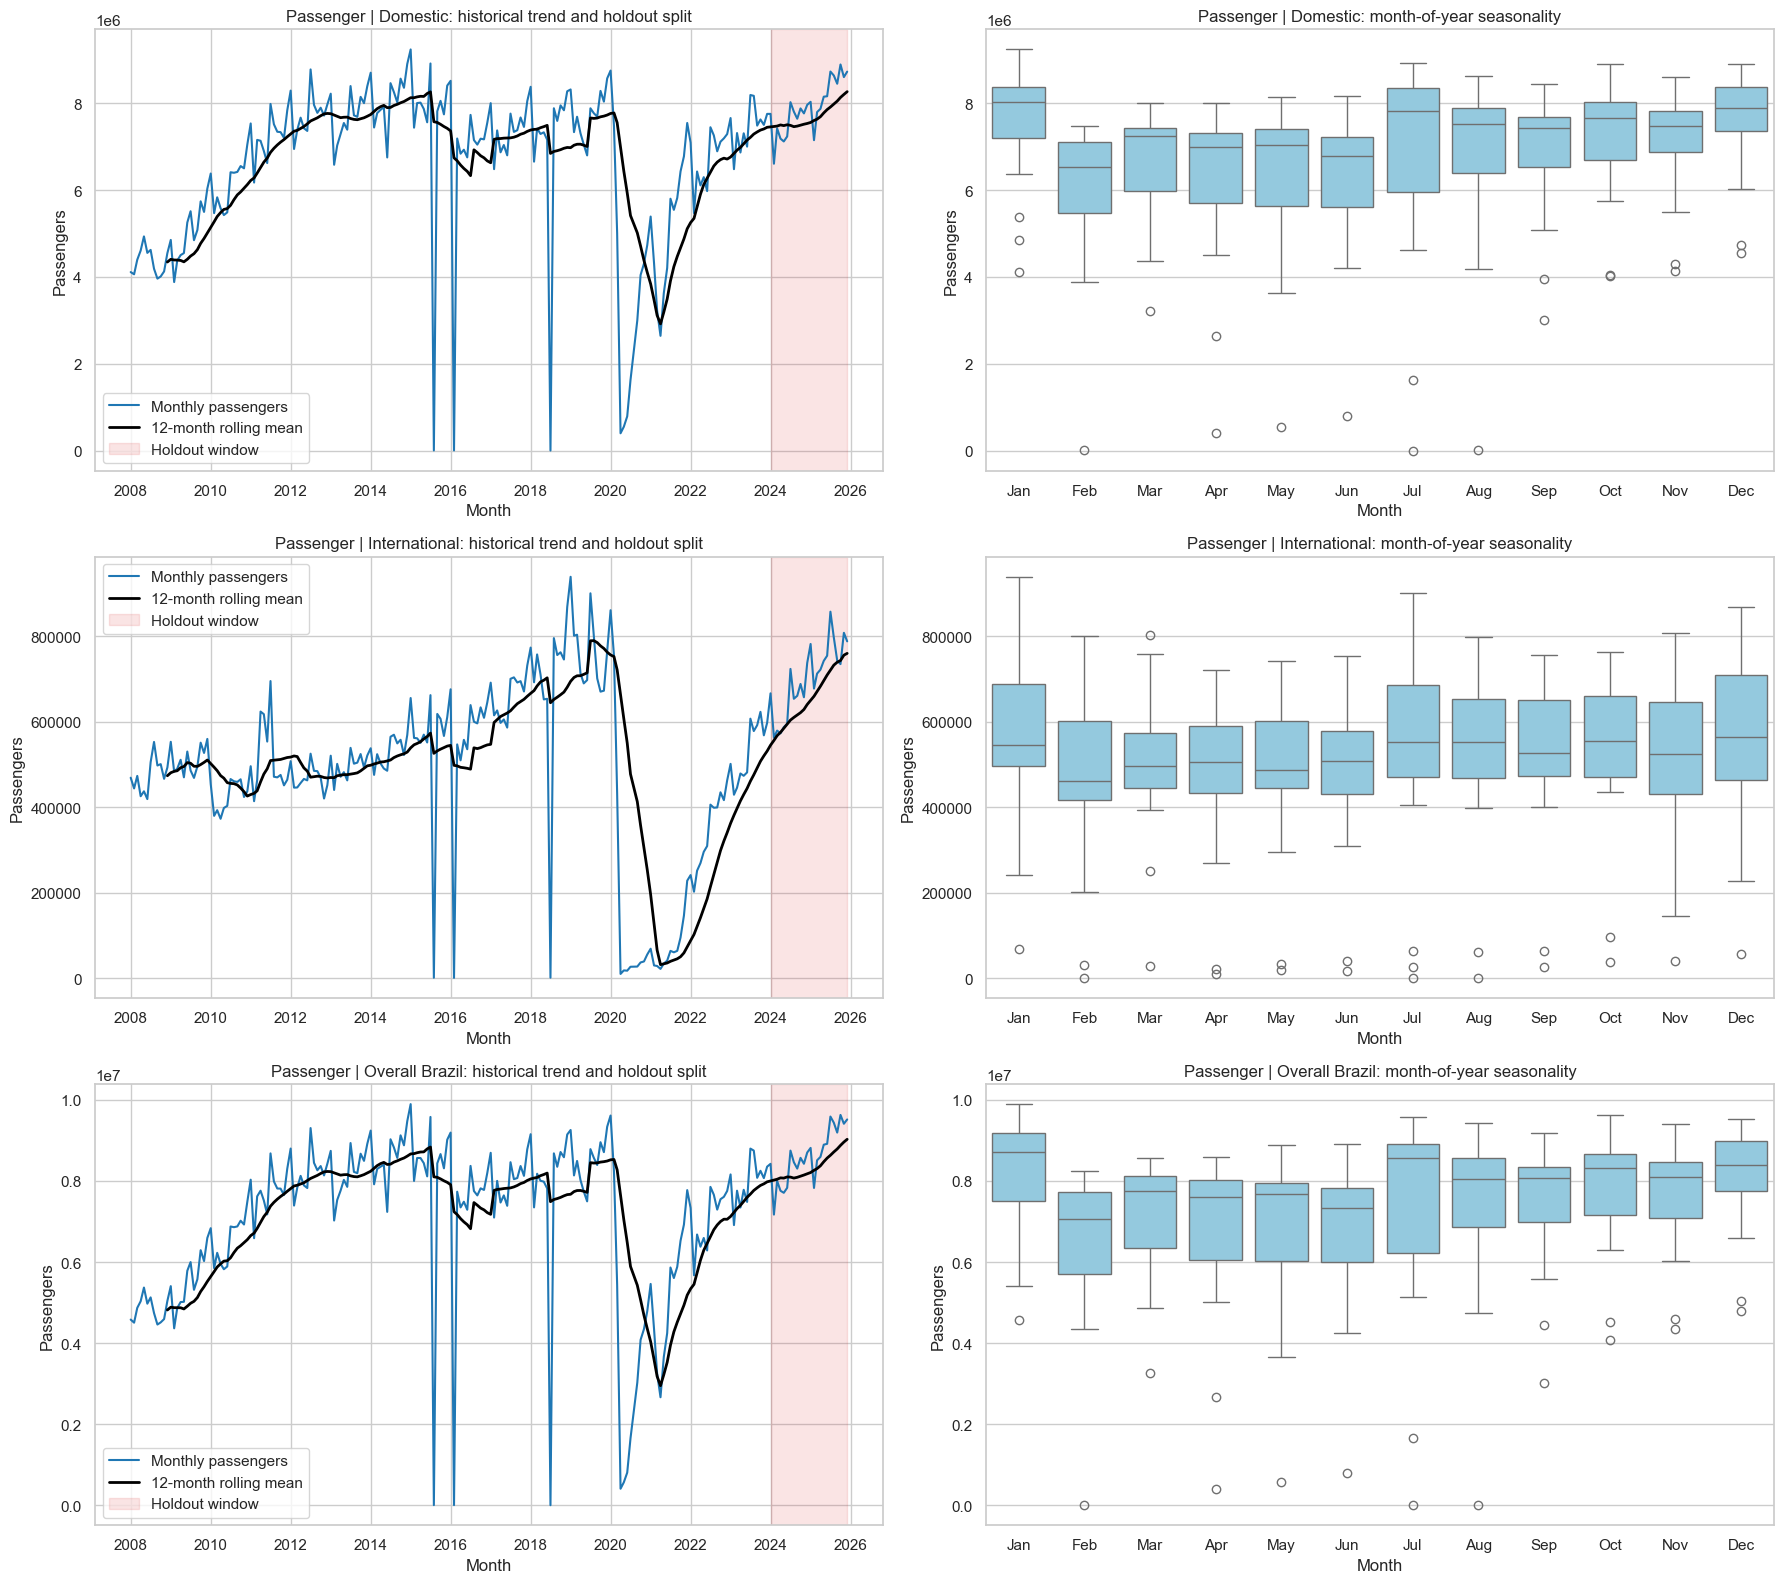

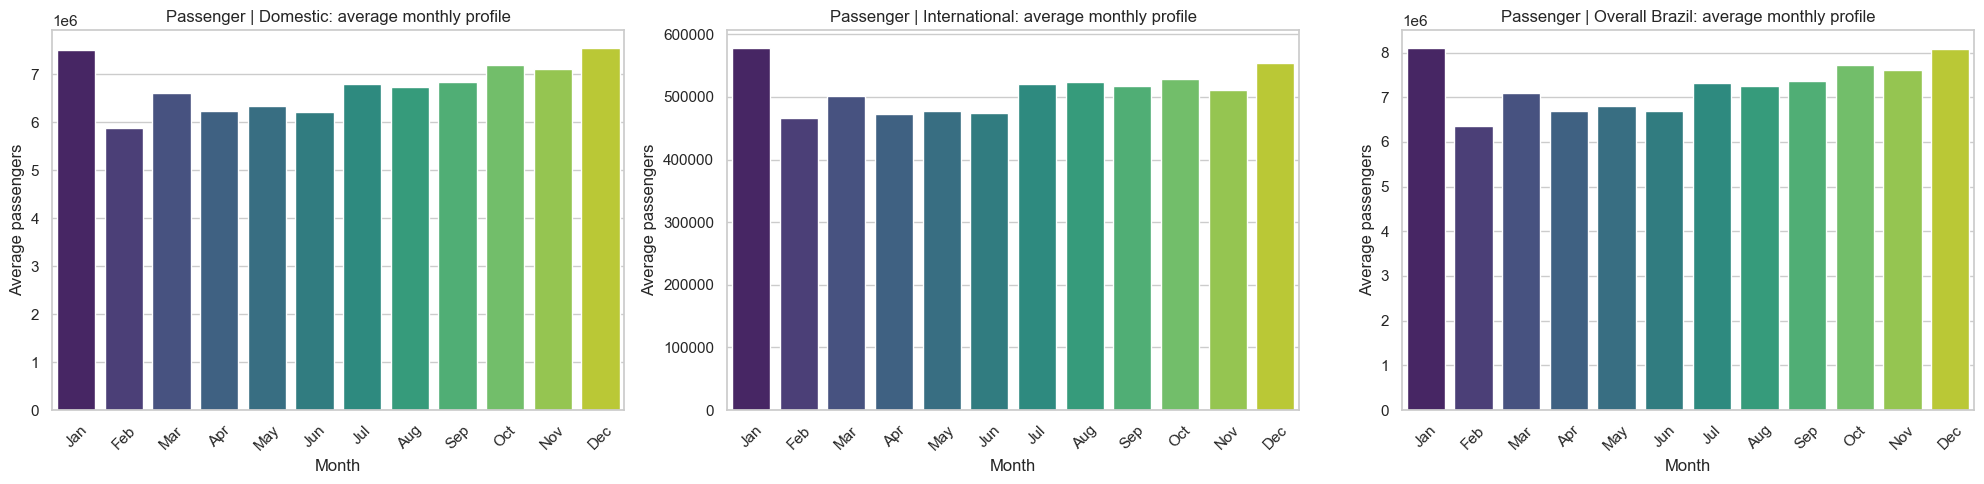

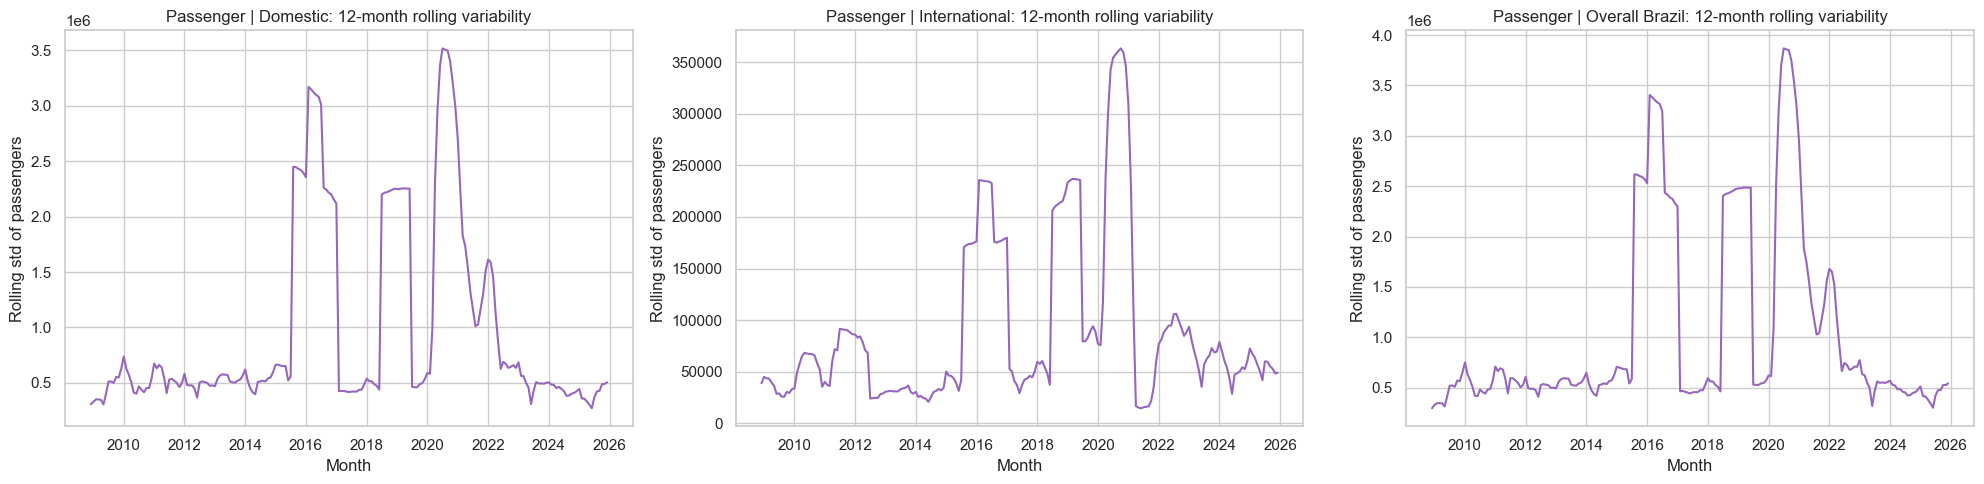

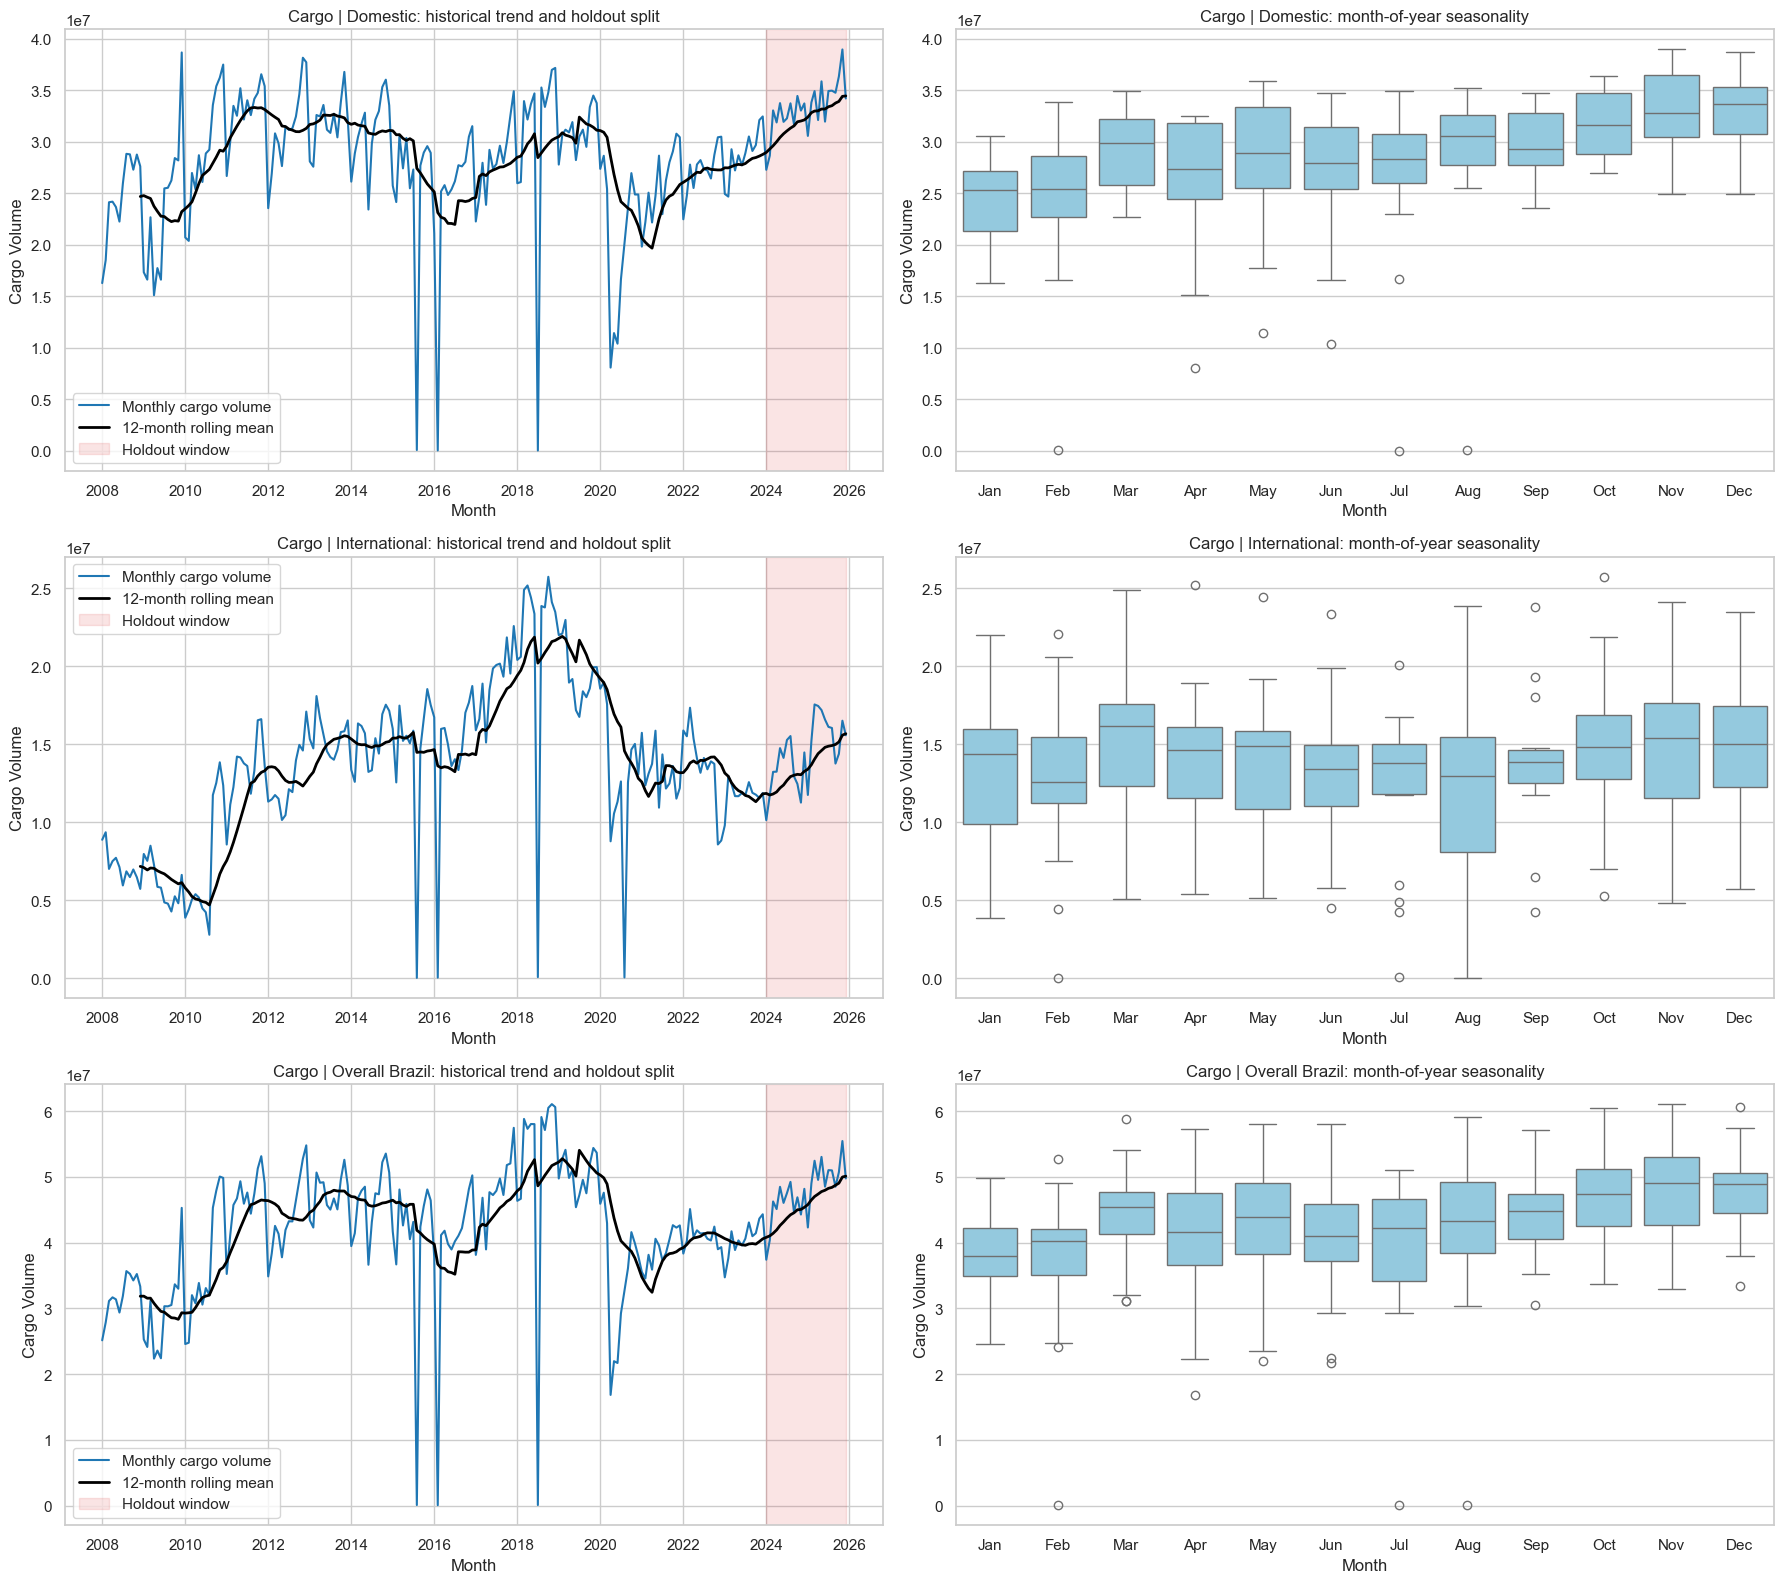

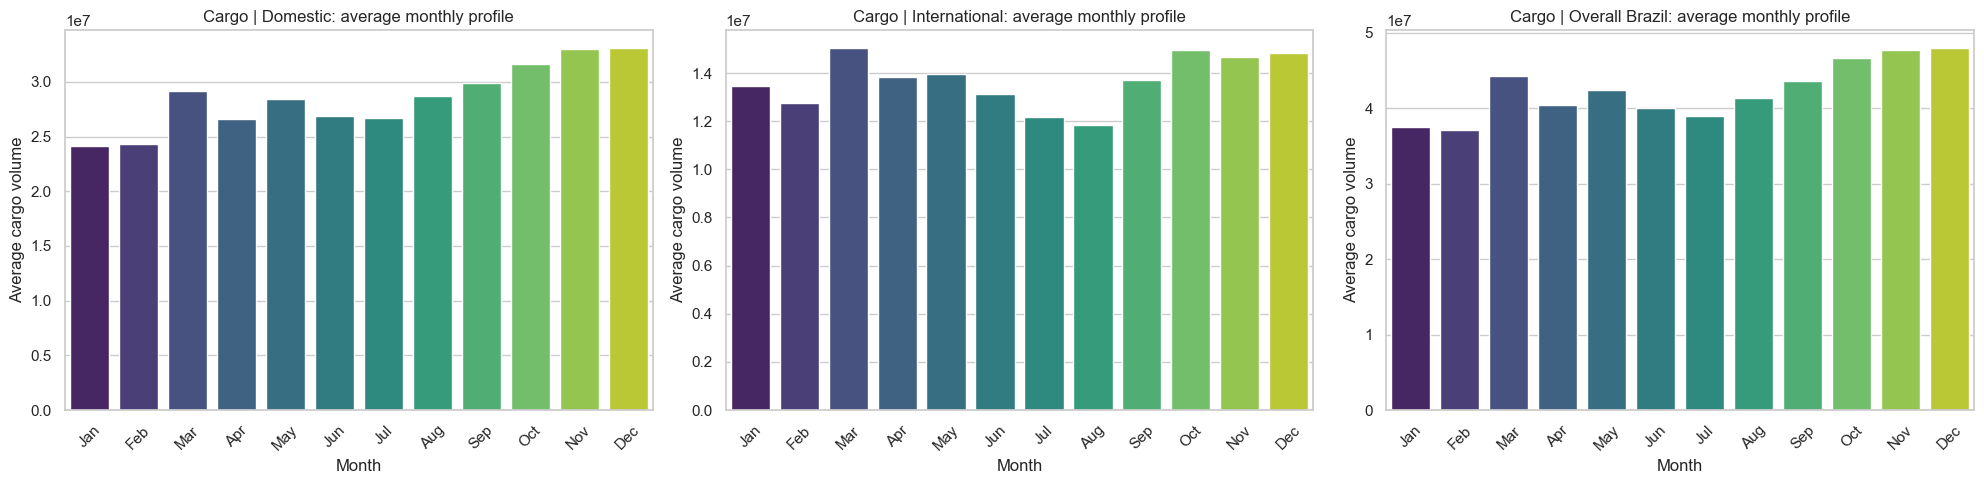

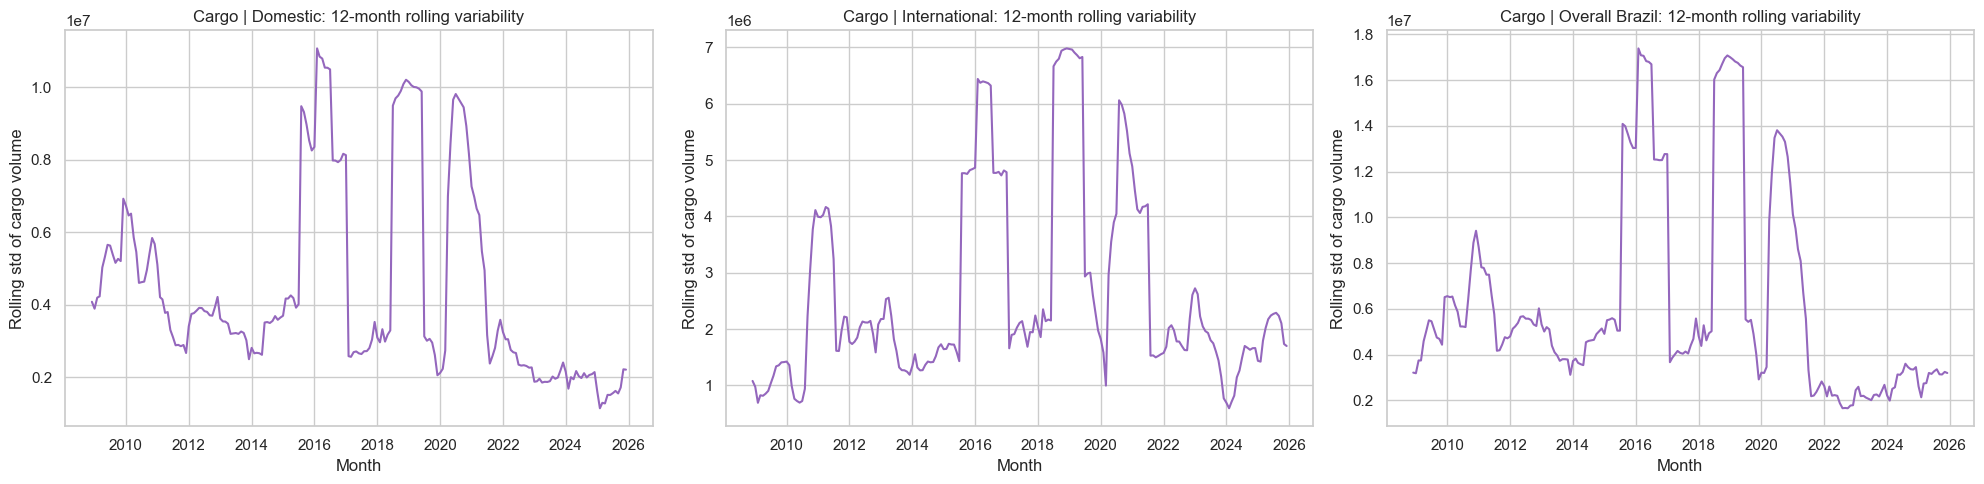

In [3]:
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for target_name, series_dict in datasets.items():
    unit_label = TARGET_CONFIGS[target_name]['unit_label']

    fig, axes = plt.subplots(3, 2, figsize=(18, 16))
    for row_idx, series_name in enumerate(SERIES_ORDER):
        frame = series_dict[series_name].copy()
        frame['rolling_mean_12'] = frame['value'].rolling(12).mean()
        test_start = frame['year_month'].iloc[-TEST_MONTHS]

        ax_left = axes[row_idx, 0]
        ax_left.plot(frame['year_month'], frame['value'], label=f'Monthly {unit_label}', color='tab:blue')
        ax_left.plot(frame['year_month'], frame['rolling_mean_12'], label='12-month rolling mean', color='black', linewidth=2)
        ax_left.axvspan(test_start, frame['year_month'].iloc[-1], color='tab:red', alpha=0.12, label='Holdout window')
        ax_left.set_title(f'{target_name} | {series_name}: historical trend and holdout split')
        ax_left.set_xlabel('Month')
        ax_left.set_ylabel(unit_label.title())
        ax_left.legend()

        ax_right = axes[row_idx, 1]
        sns.boxplot(
            x=frame['year_month'].dt.month,
            y=frame['value'],
            ax=ax_right,
            color='skyblue'
        )
        ax_right.set_title(f'{target_name} | {series_name}: month-of-year seasonality')
        ax_right.set_xlabel('Month')
        ax_right.set_ylabel(unit_label.title())
        ax_right.set_xticks(range(12))
        ax_right.set_xticklabels(month_labels)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for ax, series_name in zip(axes, SERIES_ORDER):
        frame = series_dict[series_name]
        monthly_profile = (
            frame.assign(month=frame['year_month'].dt.month)
            .groupby('month')['value']
            .mean()
            .reindex(range(1, 13))
        )
        sns.barplot(x=month_labels, y=monthly_profile.values, ax=ax, palette='viridis')
        ax.set_title(f'{target_name} | {series_name}: average monthly profile')
        ax.set_xlabel('Month')
        ax.set_ylabel(f'Average {unit_label}')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for ax, series_name in zip(axes, SERIES_ORDER):
        frame = series_dict[series_name].copy()
        frame['rolling_std_12'] = frame['value'].rolling(12).std()
        ax.plot(frame['year_month'], frame['rolling_std_12'], color='tab:purple')
        ax.set_title(f'{target_name} | {series_name}: 12-month rolling variability')
        ax.set_xlabel('Month')
        ax.set_ylabel(f'Rolling std of {unit_label}')

    plt.tight_layout()
    plt.show()

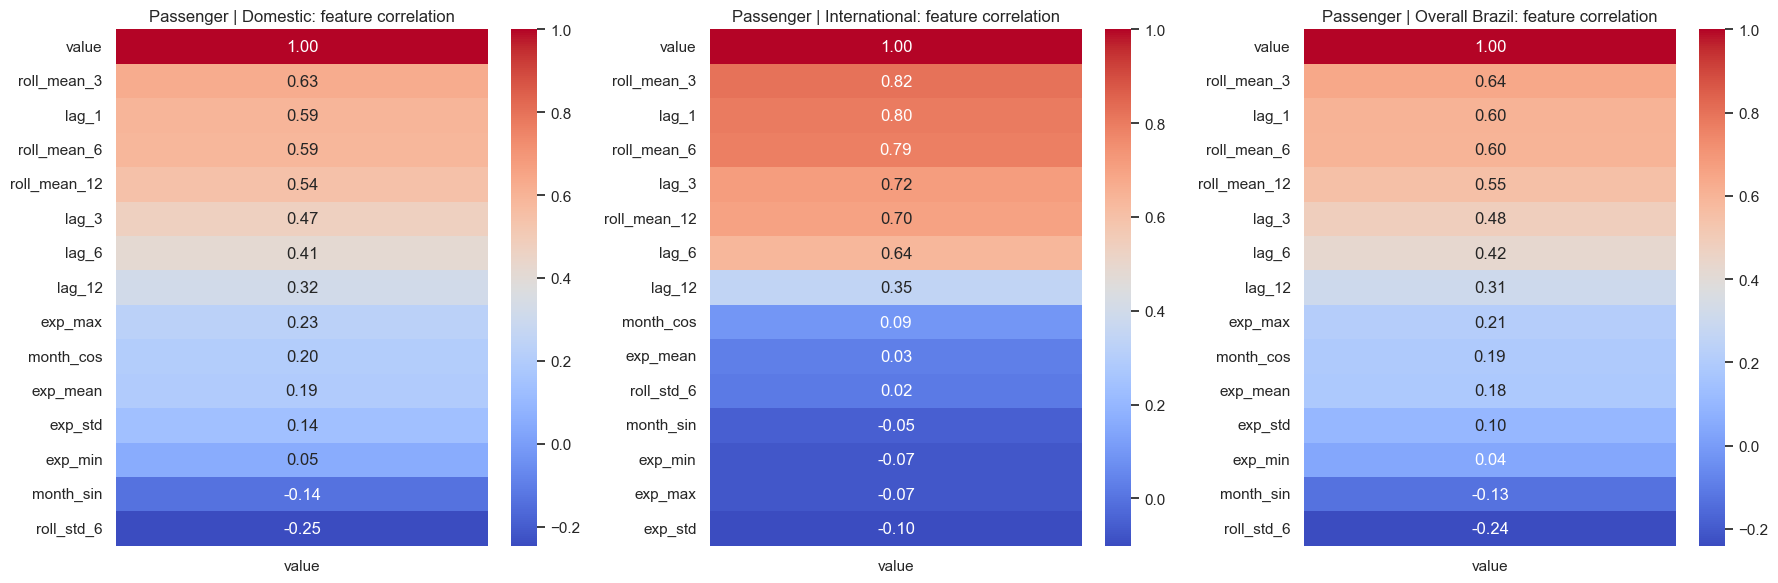

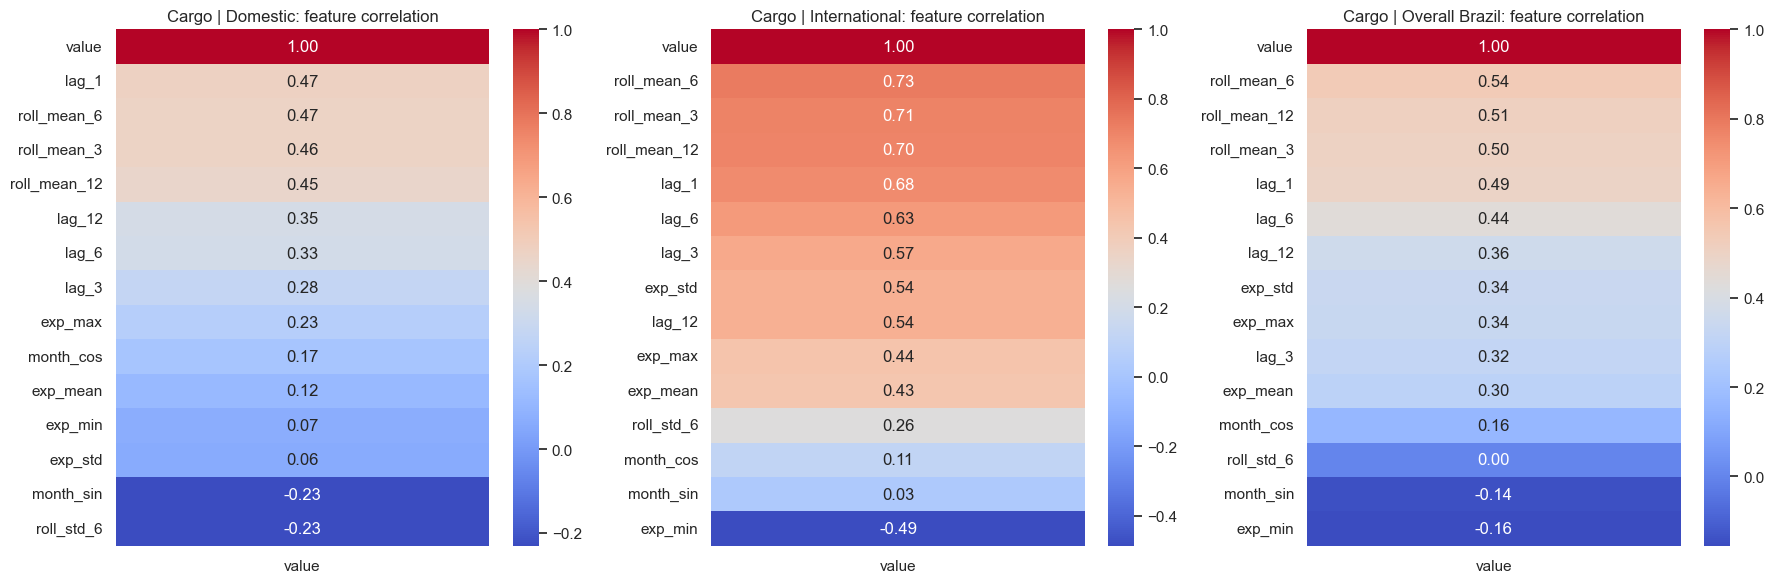

In [4]:
feature_columns_for_plot = [
    'lag_1', 'lag_3', 'lag_6', 'lag_12',
    'roll_mean_3', 'roll_mean_6', 'roll_mean_12',
    'roll_std_6', 'exp_mean', 'exp_std', 'exp_min', 'exp_max',
    'month_sin', 'month_cos'
]

for target_name, feature_dict in feature_sets.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, series_name in zip(axes, SERIES_ORDER):
        feat_df = feature_dict[series_name]
        corr = (
            feat_df[['value'] + feature_columns_for_plot]
            .dropna()
            .corr()[['value']]
            .sort_values('value', ascending=False)
        )
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
        ax.set_title(f'{target_name} | {series_name}: feature correlation')

    plt.tight_layout()
    plt.show()

## Build Model

The models are trained in increasing order of complexity for both passenger and cargo forecasting.

- **Seasonal naive** is the minimum benchmark. If a more advanced model cannot beat it, the extra complexity is not justified.
- **ETS** is used because air-traffic time series often show persistent seasonality and a smooth long-term trend.
- **SARIMAX** adds a more flexible autocorrelation structure and provides model-based prediction intervals.
- **Random forest** tests whether a nonlinear feature-based model can learn useful patterns from lags, rolling statistics, and calendar effects.

In [5]:
ML_FEATURES = [
    'time_idx', 'month', 'quarter', 'month_sin', 'month_cos',
    'lag_1', 'lag_3', 'lag_6', 'lag_12',
    'roll_mean_3', 'roll_mean_6', 'roll_mean_12',
    'roll_std_6', 'exp_mean', 'exp_std', 'exp_min', 'exp_max'
]


def chronological_split(df, test_months=TEST_MONTHS):
    train = df.iloc[:-test_months].copy().reset_index(drop=True)
    test = df.iloc[-test_months:].copy().reset_index(drop=True)
    return train, test


def score_forecast(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return {
        'MAPE': mean_absolute_percentage_error(actual, predicted) * 100,
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
    }


def next_month_index(last_observed_date, periods):
    return pd.date_range(last_observed_date + pd.offsets.MonthBegin(1), periods=periods, freq='MS')


def seasonal_naive_forecast(train_df, horizon):
    forecast_index = next_month_index(train_df['year_month'].iloc[-1], horizon)
    last_season = train_df['value'].iloc[-12:].to_numpy(dtype=float)
    forecast_values = np.tile(last_season, int(np.ceil(horizon / 12)))[:horizon]
    forecast = pd.Series(forecast_values, index=forecast_index, name='forecast')

    fitted = train_df['value'].shift(12)
    residuals = (train_df['value'] - fitted).dropna()
    scale = residuals.std(ddof=1) if len(residuals) > 1 else 0
    lower = (forecast - CONFIDENCE_Z * scale).clip(lower=0)
    upper = forecast + CONFIDENCE_Z * scale

    return {
        'forecast': forecast,
        'lower': lower,
        'upper': upper,
        'residuals': residuals,
        'parameters': {'season_length': 12},
    }


def ets_forecast(train_df, horizon):
    forecast_index = next_month_index(train_df['year_month'].iloc[-1], horizon)
    model = ExponentialSmoothing(
        train_df['value'],
        trend='add',
        damped_trend=True,
        seasonal='mul',
        seasonal_periods=12,
        initialization_method='estimated'
    ).fit(optimized=True, use_brute=True)

    forecast = model.forecast(horizon)
    forecast.index = forecast_index

    fitted = pd.Series(model.fittedvalues, index=train_df['year_month'])
    residuals = train_df['value'].reset_index(drop=True) - pd.Series(model.fittedvalues).reset_index(drop=True)
    scale = residuals.std(ddof=1) if len(residuals) > 1 else 0
    lower = (forecast - CONFIDENCE_Z * scale).clip(lower=0)
    upper = forecast + CONFIDENCE_Z * scale

    return {
        'forecast': forecast,
        'lower': lower,
        'upper': upper,
        'residuals': residuals,
        'fitted': fitted,
        'parameters': {
            'trend': 'add',
            'damped_trend': True,
            'seasonal': 'mul',
            'seasonal_periods': 12,
        },
    }


def sarimax_forecast(train_df, horizon, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)):
    forecast_index = next_month_index(train_df['year_month'].iloc[-1], horizon)
    model = SARIMAX(
        train_df['value'],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    results = model.fit(disp=False)

    forecast_results = results.get_forecast(steps=horizon)
    forecast = forecast_results.predicted_mean
    forecast.index = forecast_index

    conf_int = forecast_results.conf_int(alpha=1 - CONFIDENCE_LEVEL)
    lower = conf_int.iloc[:, 0].clip(lower=0)
    upper = conf_int.iloc[:, 1]
    lower.index = forecast_index
    upper.index = forecast_index

    fitted = pd.Series(results.fittedvalues, index=train_df['year_month'])
    residuals = pd.Series(results.resid).dropna()

    return {
        'forecast': forecast,
        'lower': lower,
        'upper': upper,
        'residuals': residuals,
        'fitted': fitted,
        'parameters': {
            'order': order,
            'seasonal_order': seasonal_order,
        },
    }


def build_feature_row(history, next_date):
    history = pd.Series(history, dtype=float)
    row = {
        'time_idx': len(history),
        'month': next_date.month,
        'quarter': next_date.quarter,
        'month_sin': np.sin(2 * np.pi * next_date.month / 12),
        'month_cos': np.cos(2 * np.pi * next_date.month / 12),
        'lag_1': history.iloc[-1],
        'lag_3': history.iloc[-3],
        'lag_6': history.iloc[-6],
        'lag_12': history.iloc[-12],
        'roll_mean_3': history.iloc[-3:].mean(),
        'roll_mean_6': history.iloc[-6:].mean(),
        'roll_mean_12': history.iloc[-12:].mean(),
        'roll_std_6': history.iloc[-6:].std(ddof=1),
        'exp_mean': history.mean(),
        'exp_std': history.std(ddof=1),
        'exp_min': history.min(),
        'exp_max': history.max(),
    }
    return row


def random_forest_forecast(train_df, horizon):
    supervised = engineer_features(train_df).dropna().reset_index(drop=True)
    X_train = supervised[ML_FEATURES]
    y_train = supervised['value']

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)

    fitted = pd.Series(model.predict(X_train), index=supervised['year_month'])
    residuals = pd.Series(y_train.to_numpy() - fitted.to_numpy())

    history = train_df['value'].tolist()
    forecast_index = next_month_index(train_df['year_month'].iloc[-1], horizon)
    forecast_values = []

    for next_date in forecast_index:
        feature_row = pd.DataFrame([build_feature_row(history, next_date)])
        prediction = float(model.predict(feature_row[ML_FEATURES])[0])
        forecast_values.append(prediction)
        history.append(prediction)

    forecast = pd.Series(forecast_values, index=forecast_index, name='forecast')
    scale = residuals.std(ddof=1) if len(residuals) > 1 else 0
    lower = (forecast - CONFIDENCE_Z * scale).clip(lower=0)
    upper = forecast + CONFIDENCE_Z * scale

    return {
        'forecast': forecast,
        'lower': lower,
        'upper': upper,
        'residuals': residuals,
        'fitted': fitted,
        'parameters': {
            'n_estimators': 500,
            'max_depth': 8,
            'min_samples_leaf': 2,
        },
    }


MODEL_BUILDERS = {
    'Seasonal Naive': seasonal_naive_forecast,
    'ETS': ets_forecast,
    'SARIMAX': sarimax_forecast,
    'Random Forest': random_forest_forecast,
}


def evaluate_all_models(dataset_collection):
    records = []
    prediction_store = {}

    for target_name, series_dict in dataset_collection.items():
        prediction_store[target_name] = {}

        for series_name, frame in series_dict.items():
            train_df, test_df = chronological_split(frame)
            prediction_store[target_name][series_name] = {}

            for model_name, builder in MODEL_BUILDERS.items():
                result = builder(train_df, len(test_df))
                metrics = score_forecast(test_df['value'], result['forecast'].to_numpy())
                records.append({
                    'target': target_name,
                    'series': series_name,
                    'model': model_name,
                    **metrics,
                })
                prediction_store[target_name][series_name][model_name] = {
                    'train': train_df,
                    'test': test_df,
                    'result': result,
                }

    metrics_df = pd.DataFrame(records).sort_values(['target', 'series', 'MAPE']).reset_index(drop=True)
    best_models = (
        metrics_df.sort_values(['target', 'series', 'MAPE'])
        .groupby(['target', 'series'], as_index=False)
        .first()
    )
    return metrics_df, best_models, prediction_store


metrics_df, best_models, prediction_store = evaluate_all_models(datasets)

print('Model comparison on the holdout window:')
display(metrics_df.round(2))

print('Best model per target and series based on holdout MAPE:')
display(best_models.round(2))

Model comparison on the holdout window:


,target,series,model,MAPE,MAE,RMSE
0,Cargo,Domestic,SARIMAX,10.76,"3,647,693.59","4,241,566.26"
1,Cargo,Domestic,Random Forest,13.17,"4,450,437.90","4,834,313.39"
2,Cargo,Domestic,Seasonal Naive,13.46,"4,515,653.67","4,908,496.25"
3,Cargo,Domestic,ETS,14.90,"5,004,018.97","5,700,417.71"
4,Cargo,International,Random Forest,17.40,"2,690,462.79","3,178,060.69"
5,Cargo,International,Seasonal Naive,18.03,"2,774,624.08","3,221,334.55"
6,Cargo,International,ETS,20.72,"3,183,023.68","3,783,929.56"
7,Cargo,International,SARIMAX,20.77,"3,199,825.55","3,834,853.15"
8,Cargo,Overall Brazil,Random Forest,12.13,"5,973,867.76","6,644,718.05"
9,Cargo,Overall Brazil,SARIMAX,14.35,"7,061,967.05","8,058,278.51"


Best model per target and series based on holdout MAPE:


,target,series,model,MAPE,MAE,RMSE
0,Cargo,Domestic,SARIMAX,10.76,"3,647,693.59","4,241,566.26"
1,Cargo,International,Random Forest,17.40,"2,690,462.79","3,178,060.69"
2,Cargo,Overall Brazil,Random Forest,12.13,"5,973,867.76","6,644,718.05"
3,Passenger,Domestic,Random Forest,6.24,"515,168.52","670,576.68"
4,Passenger,International,SARIMAX,12.23,"89,026.14","103,639.90"
5,Passenger,Overall Brazil,Random Forest,6.66,"600,369.98","814,719.63"


## Assess Model

This section compares the models using the same holdout horizon for every passenger and cargo series. The goal is not only to find the lowest error score, but also to understand whether the forecast path, seasonal shape, and residual behavior look reasonable.

A model is treated as stronger when it:
- improves on the seasonal naive baseline,
- keeps MAPE below the business threshold when possible,
- follows the level and seasonal pattern of the holdout period,
- produces residuals without strong visible structure.

The holdout winner is reported for each target and series. The final production forecasts are then chosen with an extra stability check so the 36-month horizon remains realistic and the overall Brazil forecast stays coherent with its domestic and international components.

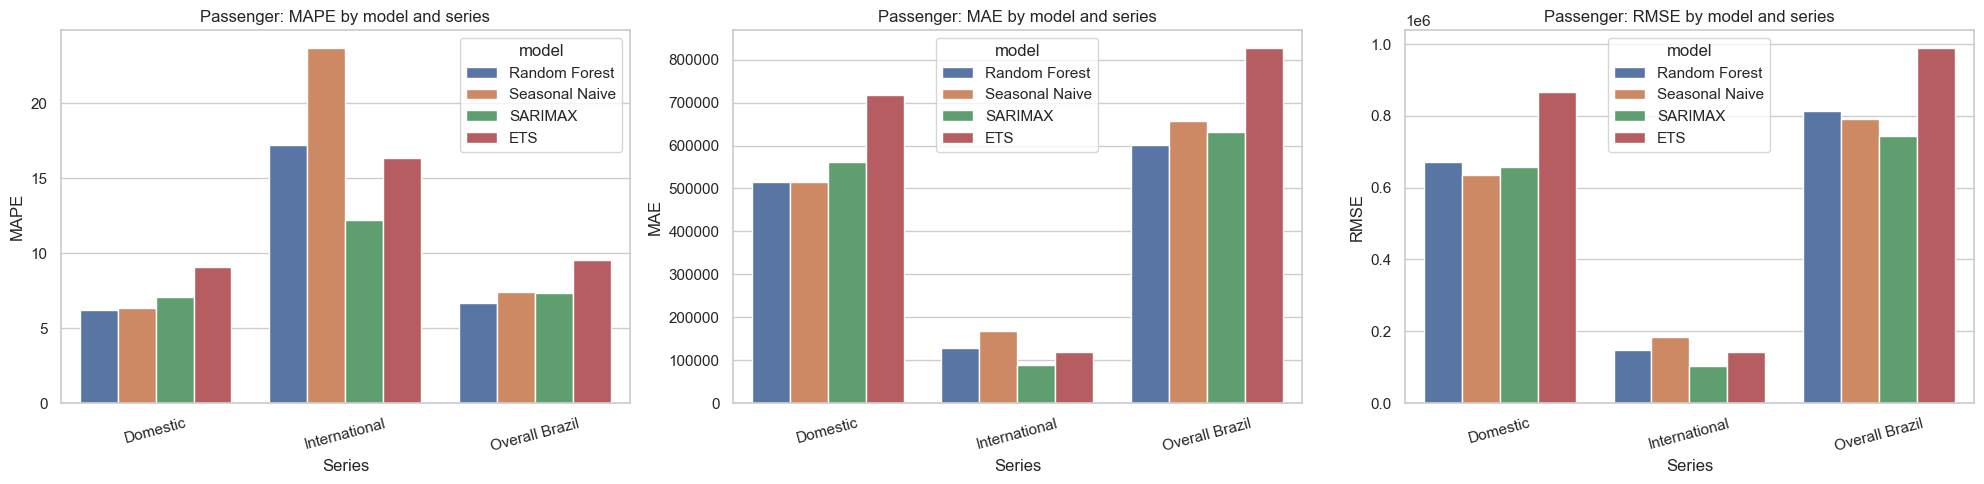

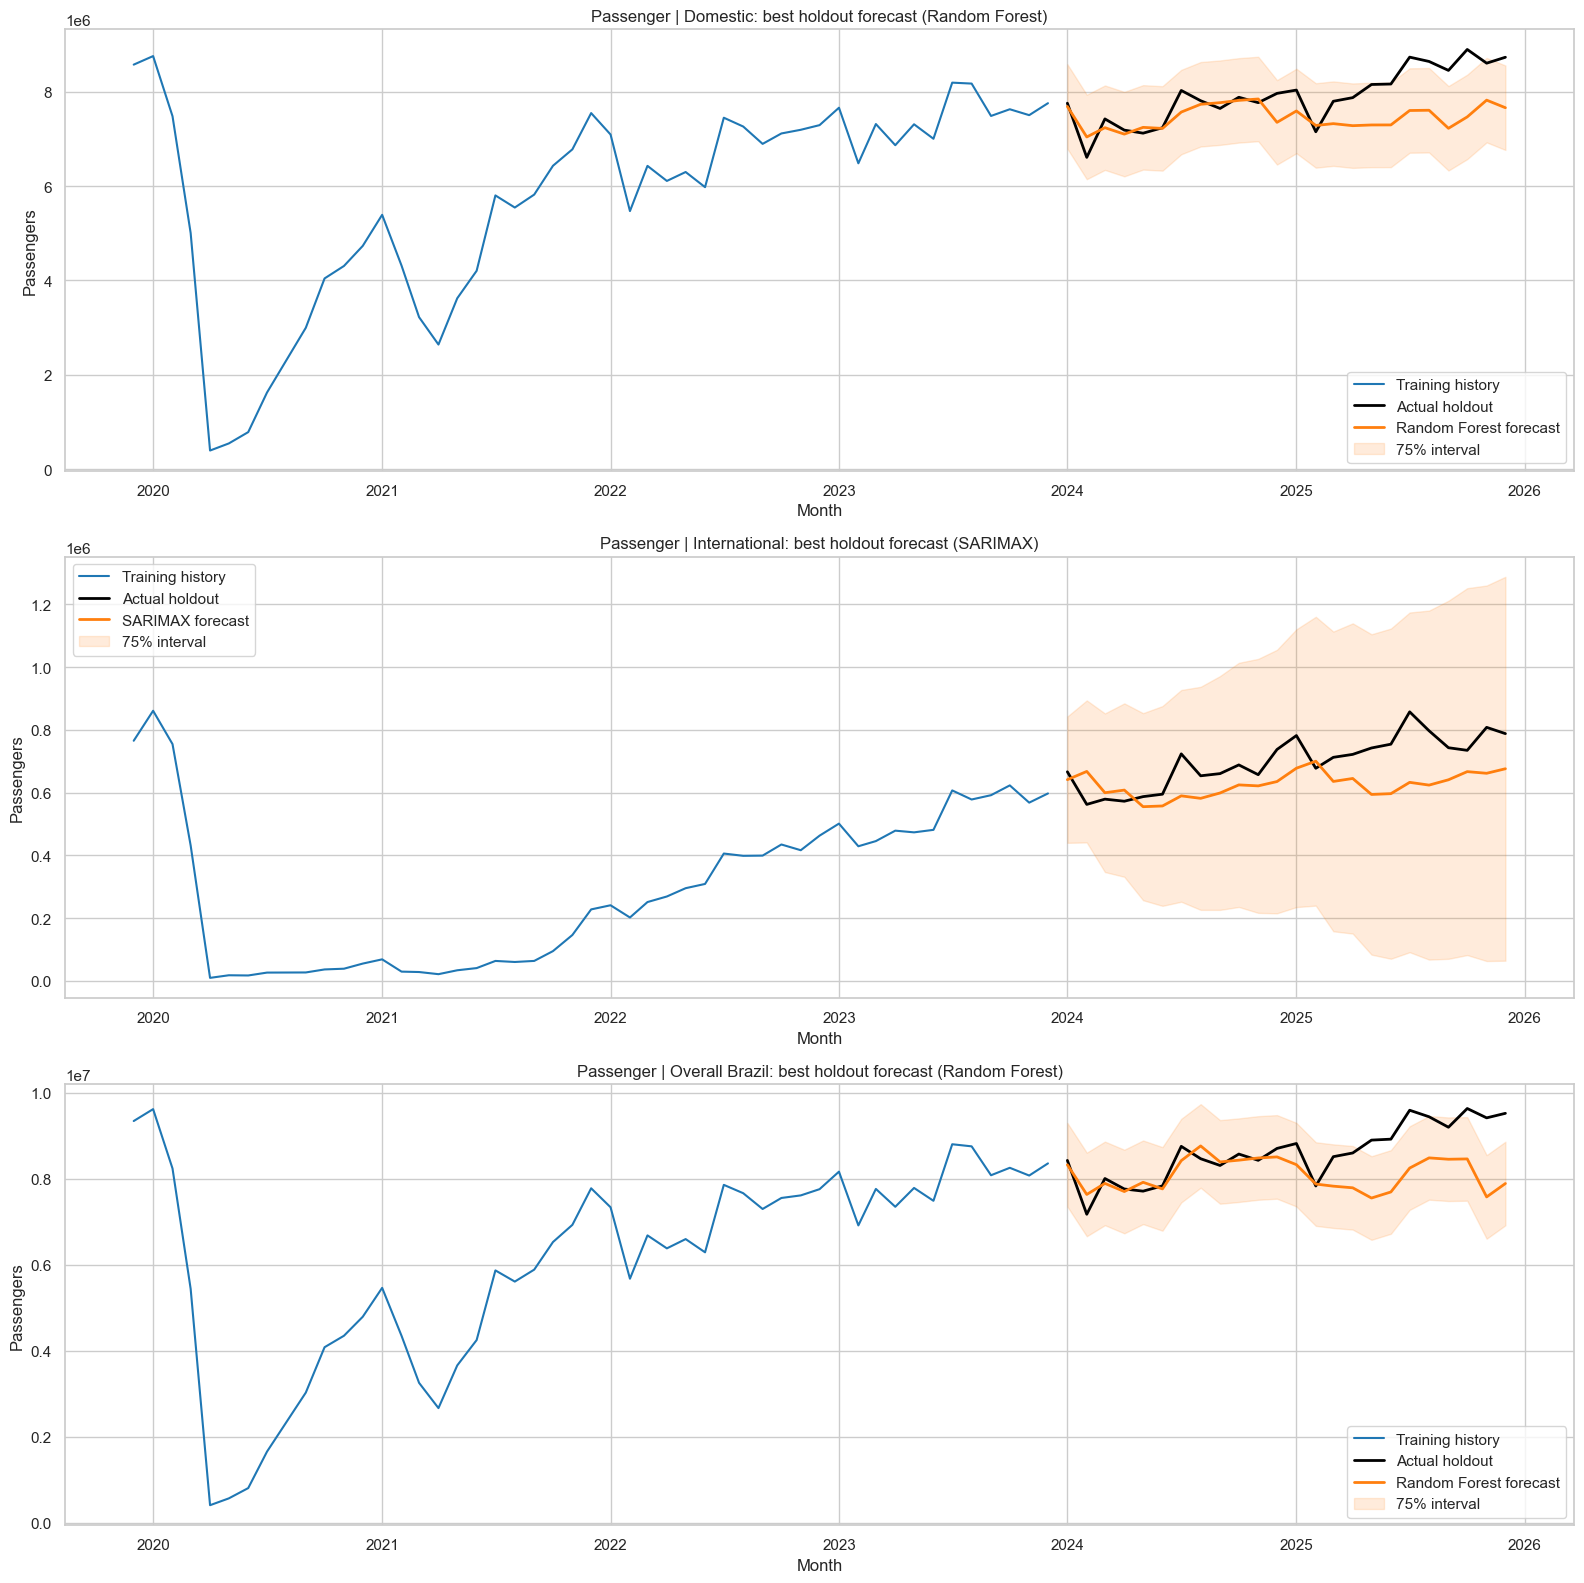

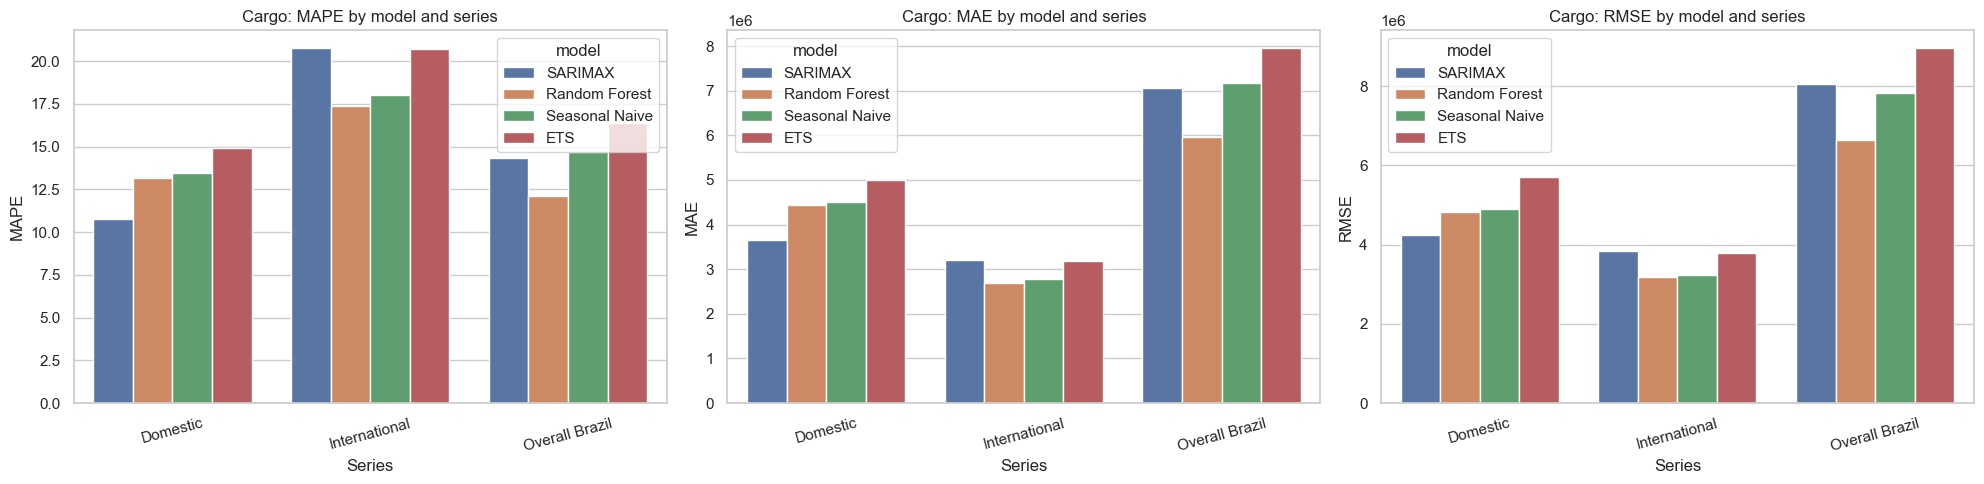

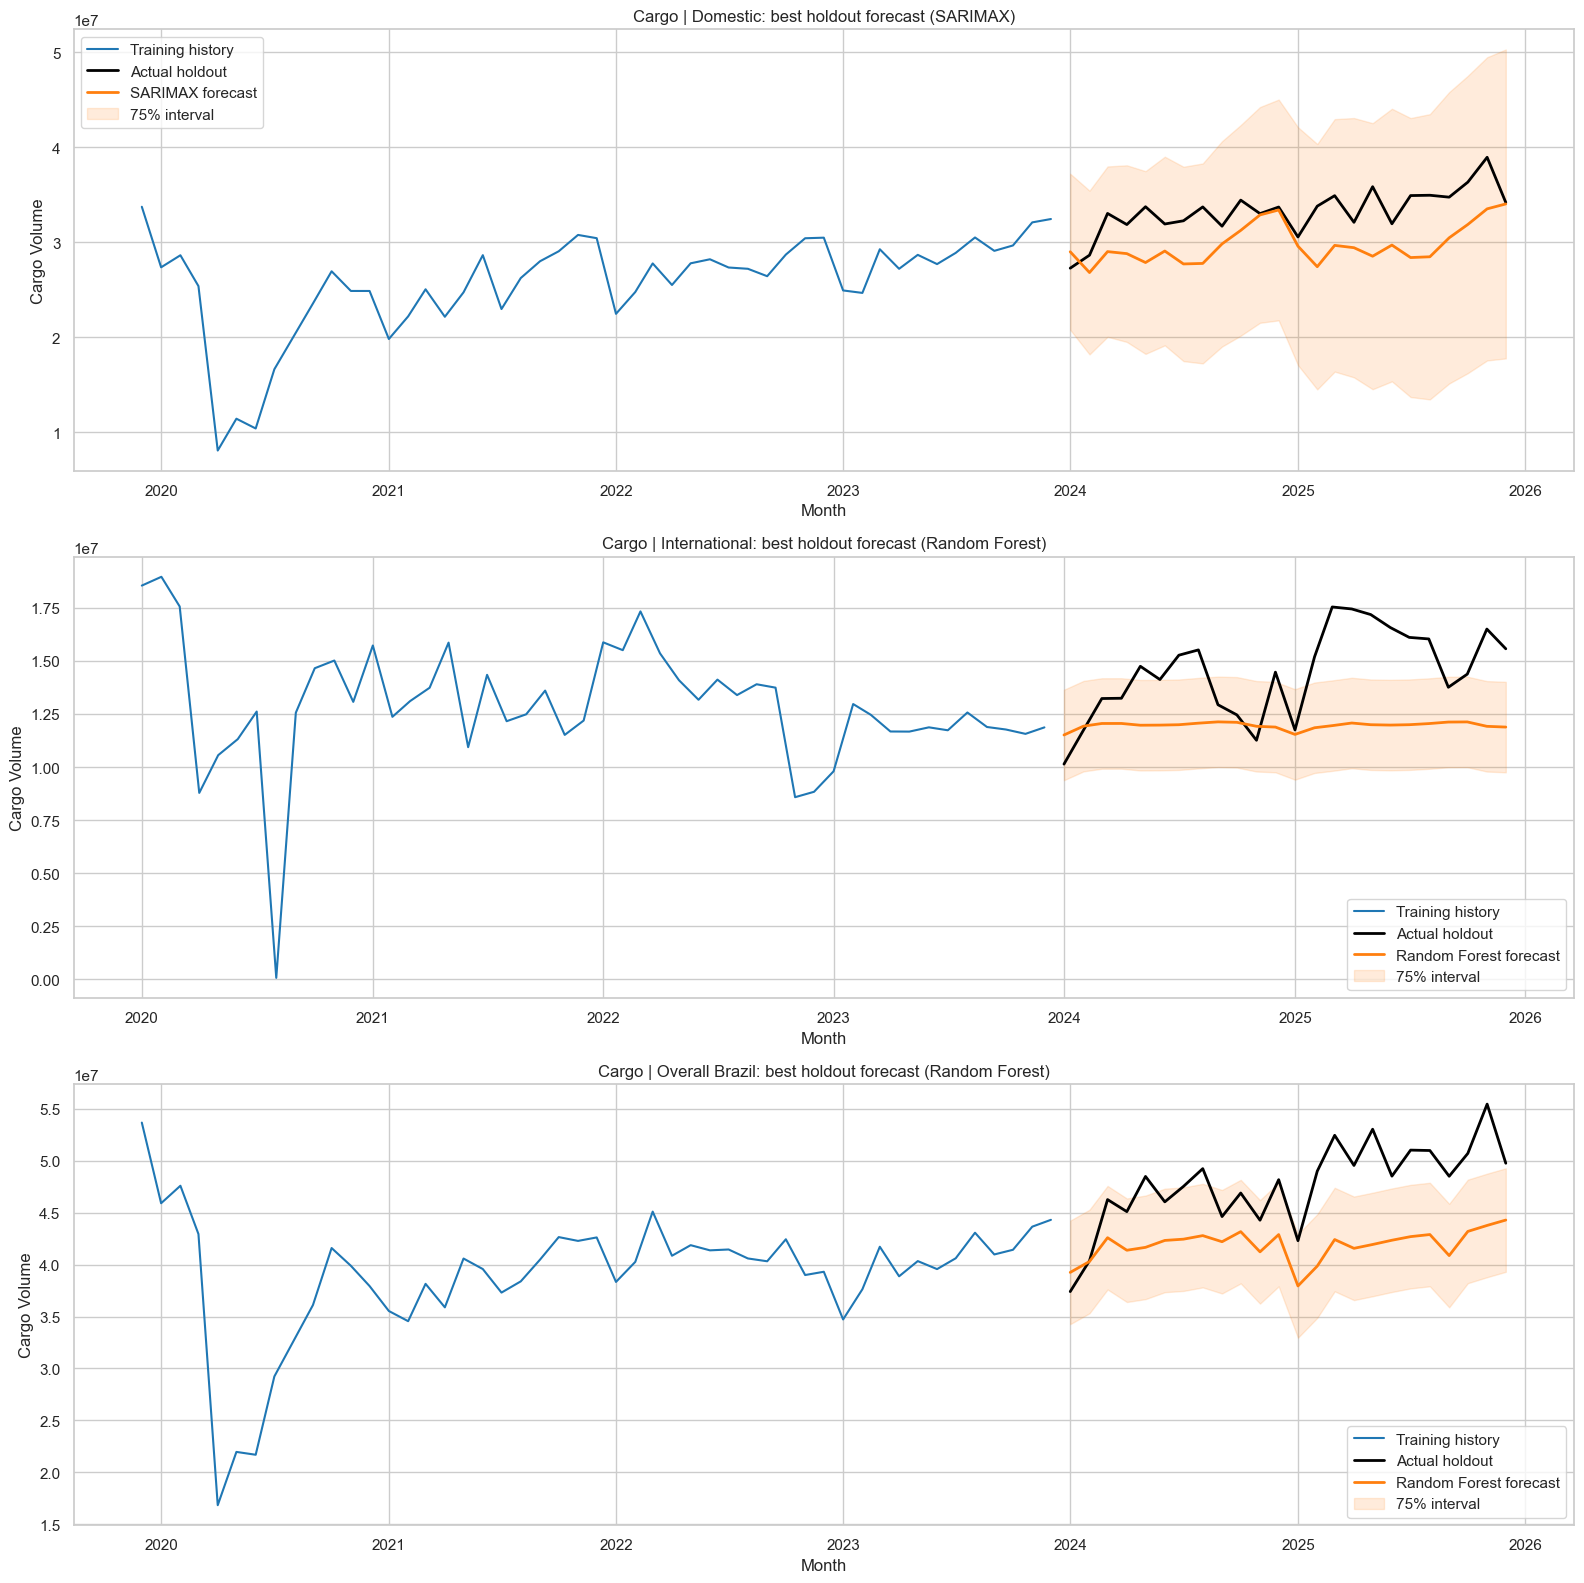

In [6]:
for target_name in TARGET_CONFIGS:
    target_metrics = metrics_df[metrics_df['target'] == target_name]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for ax, metric_name in zip(axes, ['MAPE', 'MAE', 'RMSE']):
        sns.barplot(data=target_metrics, x='series', y=metric_name, hue='model', ax=ax)
        ax.set_title(f'{target_name}: {metric_name} by model and series')
        ax.set_xlabel('Series')
        ax.set_ylabel(metric_name)
        ax.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(3, 1, figsize=(16, 16))
    target_best = best_models[best_models['target'] == target_name]
    for ax, (_, best_row) in zip(axes, target_best.iterrows()):
        series_name = best_row['series']
        model_name = best_row['model']
        bundle = prediction_store[target_name][series_name][model_name]
        train_df = bundle['train']
        test_df = bundle['test']
        forecast = bundle['result']['forecast']
        lower = bundle['result']['lower']
        upper = bundle['result']['upper']

        ax.plot(train_df['year_month'].tail(48), train_df['value'].tail(48), label='Training history', color='tab:blue')
        ax.plot(test_df['year_month'], test_df['value'], label='Actual holdout', color='black', linewidth=2)
        ax.plot(test_df['year_month'], forecast.values, label=f'{model_name} forecast', color='tab:orange', linewidth=2)
        ax.fill_between(test_df['year_month'], lower.values, upper.values, color='tab:orange', alpha=0.15, label='75% interval')
        ax.set_title(f'{target_name} | {series_name}: best holdout forecast ({model_name})')
        ax.set_xlabel('Month')
        ax.set_ylabel(TARGET_CONFIGS[target_name]['unit_label'].title())
        ax.legend()

    plt.tight_layout()
    plt.show()

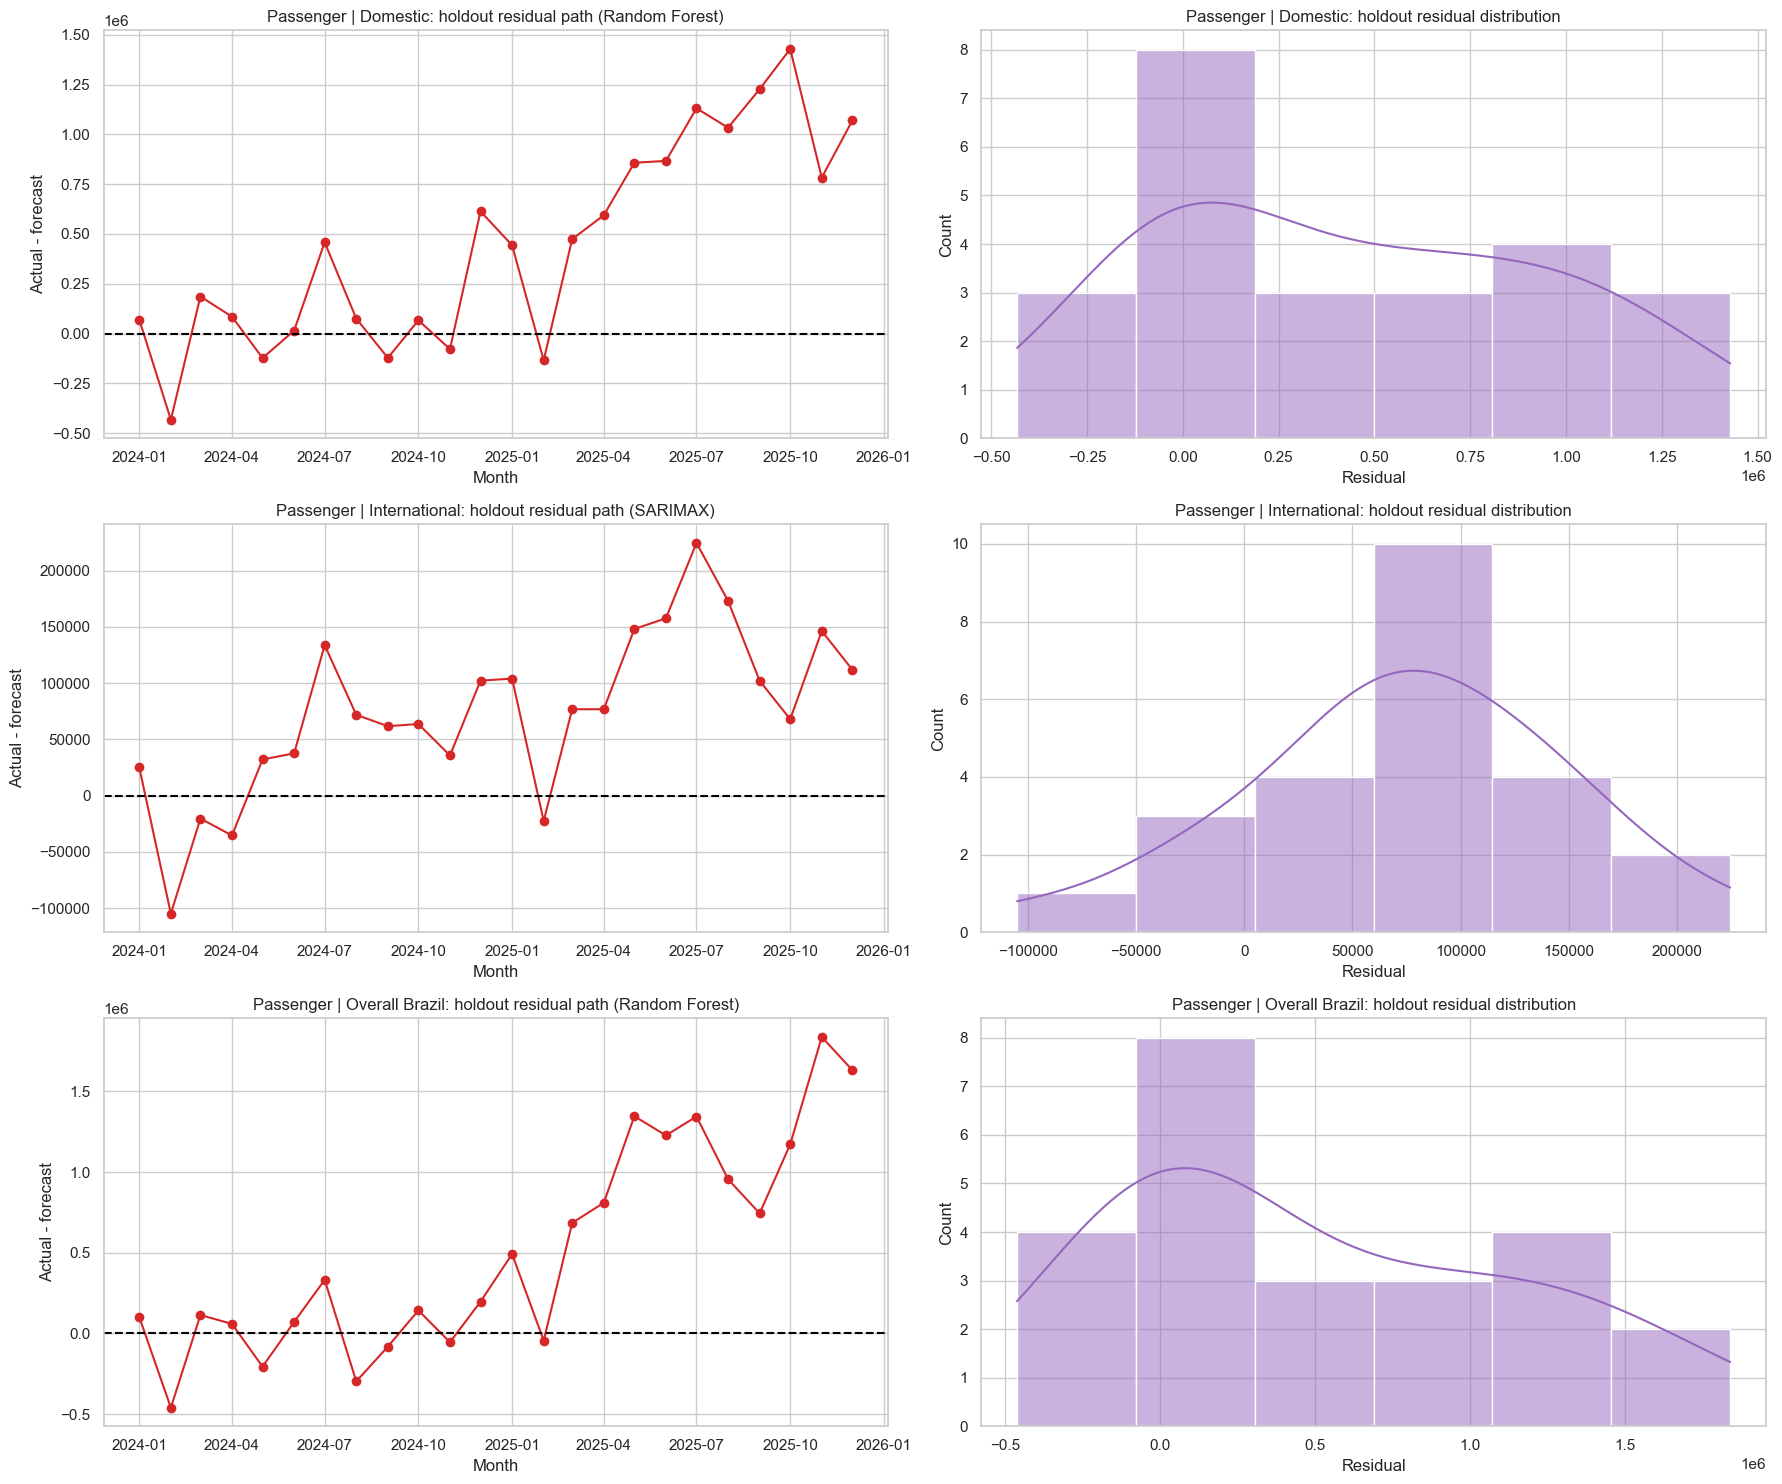

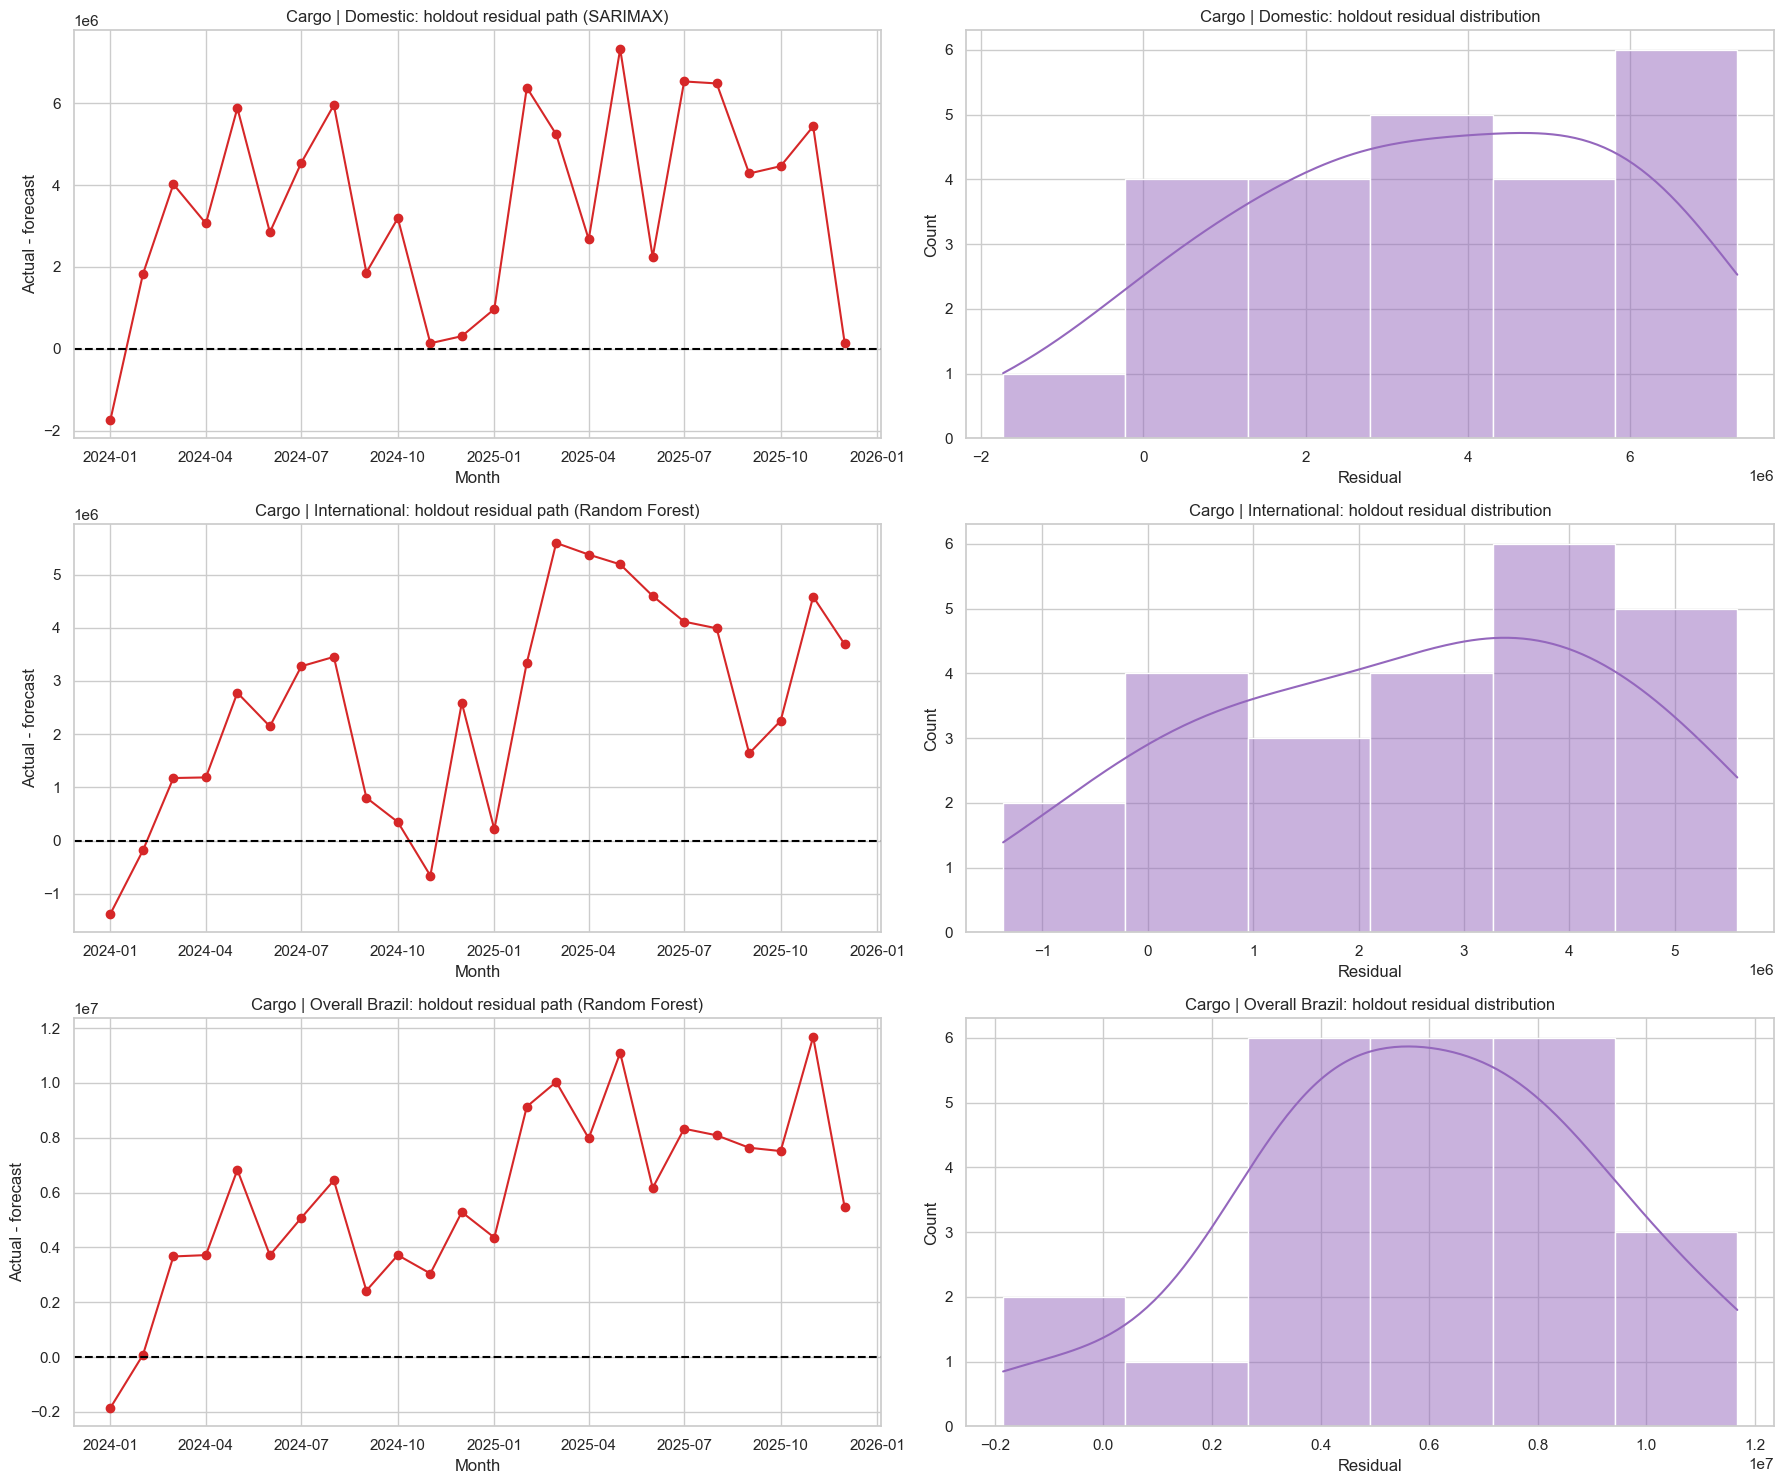

,target,series,model,MAPE,MAE,RMSE,meets_business_target
0,Cargo,Domestic,SARIMAX,10.76,"3,647,693.59","4,241,566.26",True
1,Cargo,International,Random Forest,17.40,"2,690,462.79","3,178,060.69",True
2,Cargo,Overall Brazil,Random Forest,12.13,"5,973,867.76","6,644,718.05",True
3,Passenger,Domestic,Random Forest,6.24,"515,168.52","670,576.68",True
4,Passenger,International,SARIMAX,12.23,"89,026.14","103,639.90",True
5,Passenger,Overall Brazil,Random Forest,6.66,"600,369.98","814,719.63",True


In [7]:
for target_name in TARGET_CONFIGS:
    fig, axes = plt.subplots(3, 2, figsize=(18, 15))
    target_best = best_models[best_models['target'] == target_name]

    for row_idx, (_, best_row) in enumerate(target_best.iterrows()):
        series_name = best_row['series']
        model_name = best_row['model']
        bundle = prediction_store[target_name][series_name][model_name]
        test_df = bundle['test']
        forecast = bundle['result']['forecast']
        residuals = test_df['value'].to_numpy() - forecast.to_numpy()

        ax_left = axes[row_idx, 0]
        ax_left.plot(test_df['year_month'], residuals, marker='o', color='tab:red')
        ax_left.axhline(0, color='black', linestyle='--')
        ax_left.set_title(f'{target_name} | {series_name}: holdout residual path ({model_name})')
        ax_left.set_xlabel('Month')
        ax_left.set_ylabel('Actual - forecast')

        ax_right = axes[row_idx, 1]
        sns.histplot(residuals, kde=True, ax=ax_right, color='tab:purple')
        ax_right.set_title(f'{target_name} | {series_name}: holdout residual distribution')
        ax_right.set_xlabel('Residual')

    plt.tight_layout()
    plt.show()

assessment_table = best_models.copy()
assessment_table['meets_business_target'] = assessment_table['MAPE'].lt(20)
display(assessment_table.round(2))

## Final Forecast Generation

The lowest holdout MAPE is not the only selection criterion for the final forecast. For a 36-month horizon, the forecast also needs to remain stable, interpretable, and able to produce reliable prediction intervals.

In this notebook, **SARIMAX** is chosen as the final production model for passenger and cargo component series because it:
- stays below the business error threshold in the main holdout comparisons,
- handles trend and annual seasonality directly,
- provides native prediction intervals,
- gives a more stable long-horizon trajectory than the recursive random-forest alternative,
- gives more reasonable and useful 75% prediction interval.

For each target, the final overall Brazil forecast is then built as a **coherent sum** of the domestic and international forecasts. A direct SARIMAX model for the national total is kept as a benchmark for comparison.

Each forecast includes a **75% prediction interval** so the output is not limited to a single point estimate. This is important for planning because airport and infrastructure decisions should consider a plausible range, not only the most likely value.

In [8]:
FINAL_COMPONENT_MODEL = 'SARIMAX'


def build_final_forecasts(dataset_collection, horizon=FORECAST_HORIZON):
    final_outputs = {}
    direct_overall_outputs = {}

    for target_name, series_dict in dataset_collection.items():
        component_outputs = {}

        for series_name in ['Domestic', 'International']:
            result = MODEL_BUILDERS[FINAL_COMPONENT_MODEL](series_dict[series_name], horizon)
            forecast_df = pd.DataFrame({
                'year_month': result['forecast'].index,
                'forecast_value': result['forecast'].values,
                'lower_75': result['lower'].values,
                'upper_75': result['upper'].values,
            })
            component_outputs[series_name] = {
                'model_name': FINAL_COMPONENT_MODEL,
                'result': result,
                'forecast_df': forecast_df,
            }

        direct_overall_result = MODEL_BUILDERS[FINAL_COMPONENT_MODEL](series_dict['Overall Brazil'], horizon)
        direct_overall_outputs[target_name] = {
            'model_name': FINAL_COMPONENT_MODEL,
            'result': direct_overall_result,
            'forecast_df': pd.DataFrame({
                'year_month': direct_overall_result['forecast'].index,
                'forecast_value': direct_overall_result['forecast'].values,
                'lower_75': direct_overall_result['lower'].values,
                'upper_75': direct_overall_result['upper'].values,
            })
        }

        domestic_forecast = component_outputs['Domestic']['forecast_df']
        international_forecast = component_outputs['International']['forecast_df']
        overall_forecast = domestic_forecast.merge(
            international_forecast,
            on='year_month',
            suffixes=('_domestic', '_international')
        )
        overall_forecast['forecast_value'] = (
            overall_forecast['forecast_value_domestic'] +
            overall_forecast['forecast_value_international']
        )
        overall_forecast['lower_75'] = overall_forecast['lower_75_domestic'] + overall_forecast['lower_75_international']
        overall_forecast['upper_75'] = overall_forecast['upper_75_domestic'] + overall_forecast['upper_75_international']
        overall_forecast = overall_forecast[['year_month', 'forecast_value', 'lower_75', 'upper_75']]

        final_outputs[target_name] = {
            **component_outputs,
            'Overall Brazil': {
                'model_name': 'Coherent sum of domestic and international SARIMAX forecasts',
                'result': None,
                'forecast_df': overall_forecast,
            }
        }

    return final_outputs, direct_overall_outputs


final_outputs, direct_overall_outputs = build_final_forecasts(datasets)

final_model_selection_df = pd.DataFrame([
    {
        'target': target_name,
        'series': series_name,
        'selected_final_model': output['model_name'],
    }
    for target_name, target_outputs in final_outputs.items()
    for series_name, output in target_outputs.items()
])
display(final_model_selection_df)

for target_name, target_outputs in final_outputs.items():
    print(f'{target_name} forecasts')
    for series_name, output in target_outputs.items():
        print(f"{series_name} | final model: {output['model_name']}")
        display(output['forecast_df'].head())
    print(f"Direct overall benchmark model: {direct_overall_outputs[target_name]['model_name']}")

,target,series,selected_final_model
0,Passenger,Domestic,SARIMAX
1,Passenger,International,SARIMAX
2,Passenger,Overall Brazil,Coherent sum of domestic and international SAR...
3,Cargo,Domestic,SARIMAX
4,Cargo,International,SARIMAX
5,Cargo,Overall Brazil,Coherent sum of domestic and international SAR...


Passenger forecasts
Domestic | final model: SARIMAX


,year_month,forecast_value,lower_75,upper_75
0,2026-01-01,"9,112,288.13","7,066,388.37","11,158,187.88"
1,2026-02-01,"8,393,673.02","6,168,555.90","10,618,790.13"
2,2026-03-01,"8,303,301.73","5,937,436.08","10,669,167.39"
3,2026-04-01,"8,243,152.95","5,745,837.71","10,740,468.18"
4,2026-05-01,"8,128,790.84","5,506,687.04","10,750,894.64"


International | final model: SARIMAX


,year_month,forecast_value,lower_75,upper_75
0,2026-01-01,"846,409.79","657,190.80","1,035,628.78"
1,2026-02-01,"824,196.98","611,579.34","1,036,814.63"
2,2026-03-01,"790,743.35","553,918.18","1,027,568.52"
3,2026-04-01,"796,915.68","538,372.55","1,055,458.81"
4,2026-05-01,"767,870.33","489,279.98","1,046,460.68"


...

International | final model: SARIMAX


,year_month,forecast_value,lower_75,upper_75
0,2026-01-01,"15,261,959.41","10,185,434.63","20,338,484.19"
1,2026-02-01,"15,955,845.05","10,586,203.39","21,325,486.71"
2,2026-03-01,"17,811,207.34","12,248,334.77","23,374,079.91"
3,2026-04-01,"16,654,796.14","10,911,801.93","22,397,790.34"
4,2026-05-01,"16,961,582.06","11,044,513.20","22,878,650.92"


Overall Brazil | final model: Coherent sum of domestic and international SARIMAX forecasts


,year_month,forecast_value,lower_75,upper_75
0,2026-01-01,"48,231,431.47","35,415,236.76","61,047,626.17"
1,2026-02-01,"49,262,392.76","35,780,982.56","62,743,802.96"
2,2026-03-01,"53,593,469.09","39,599,194.89","67,587,743.30"
3,2026-04-01,"51,138,791.72","36,657,270.83","65,620,312.61"
4,2026-05-01,"52,543,751.70","37,591,484.28","67,496,019.12"


Direct overall benchmark model: SARIMAX


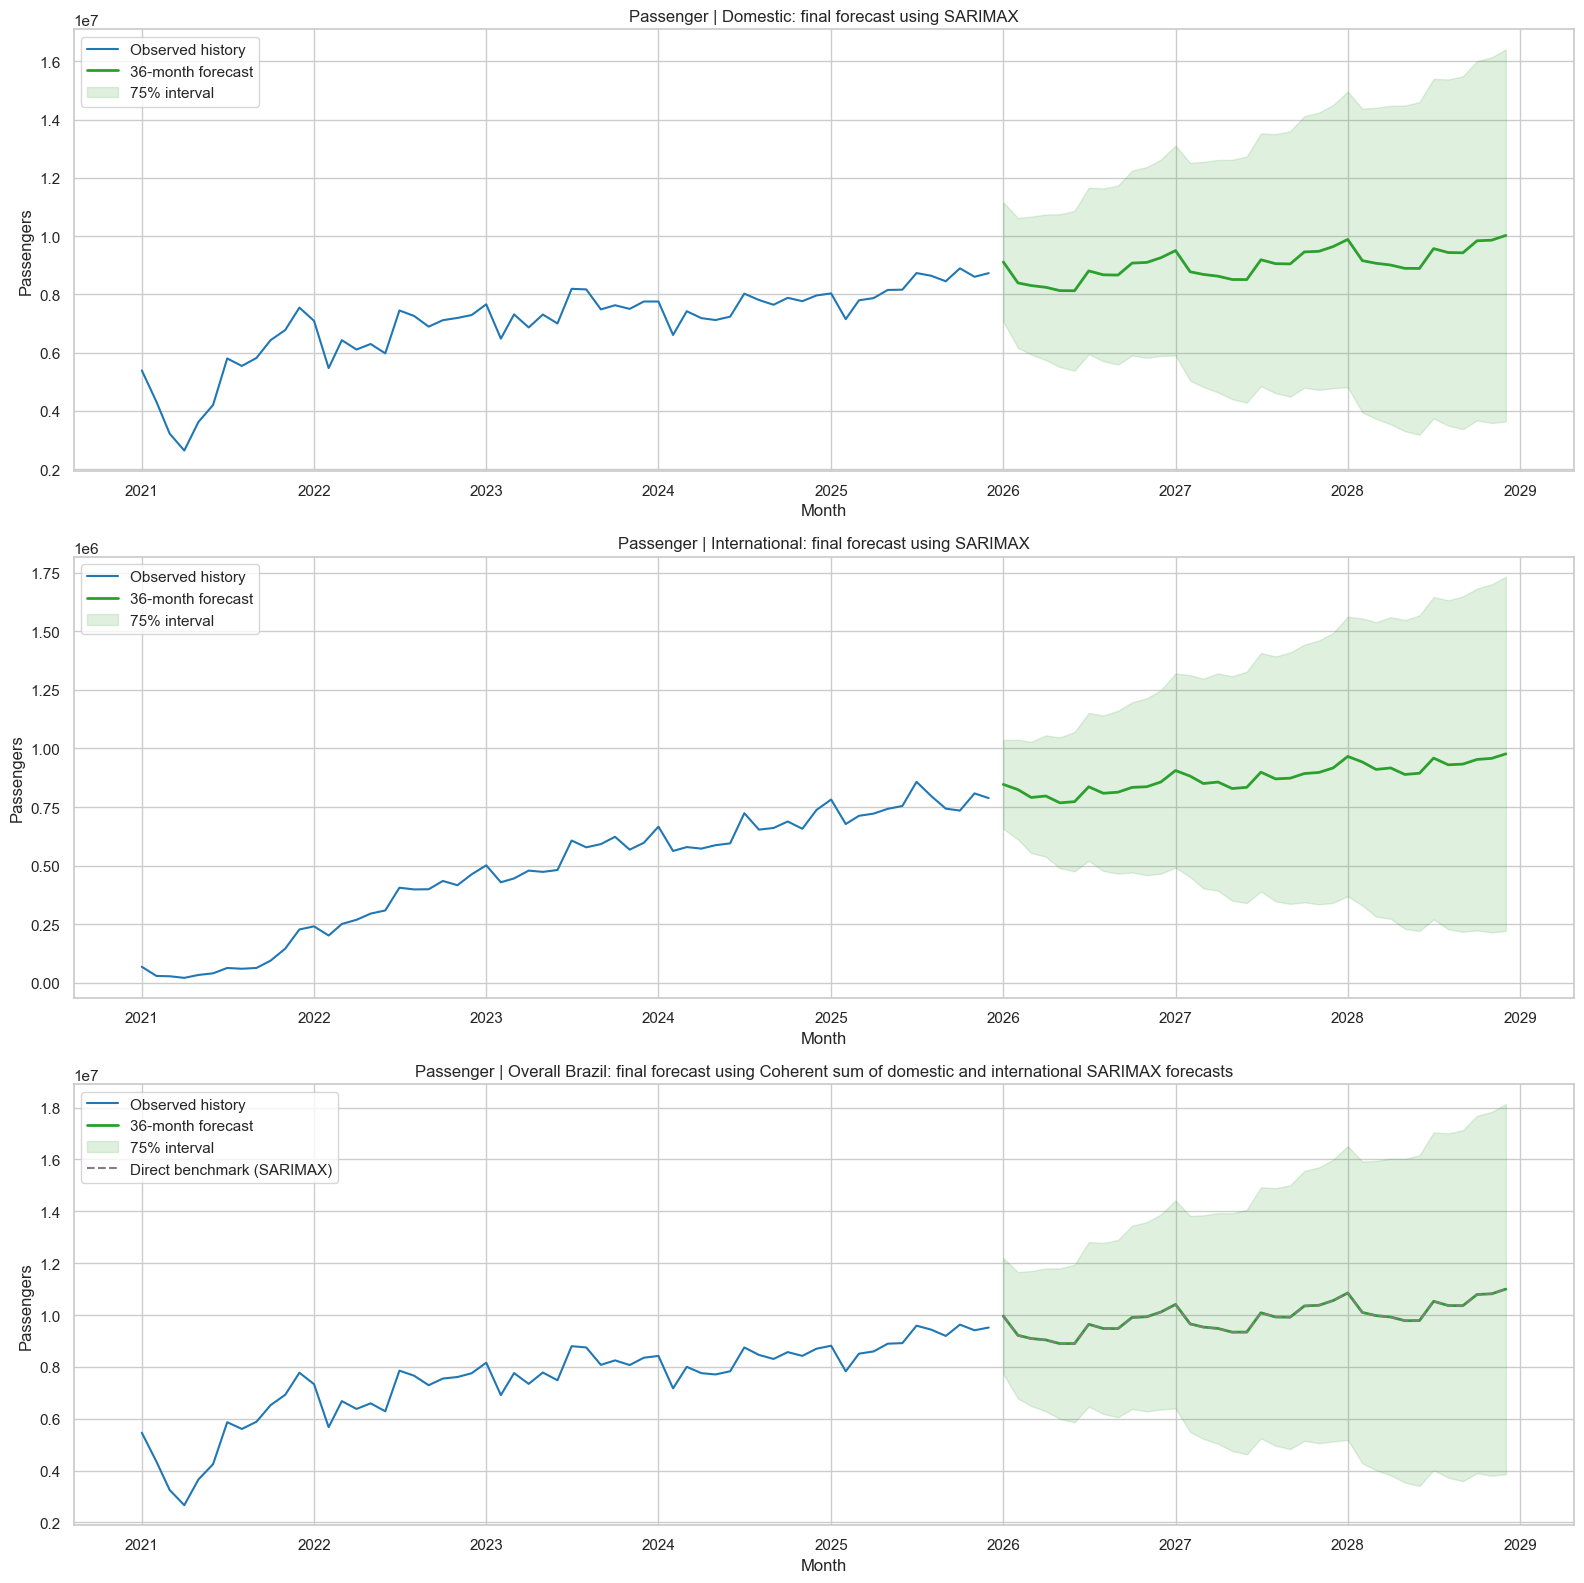

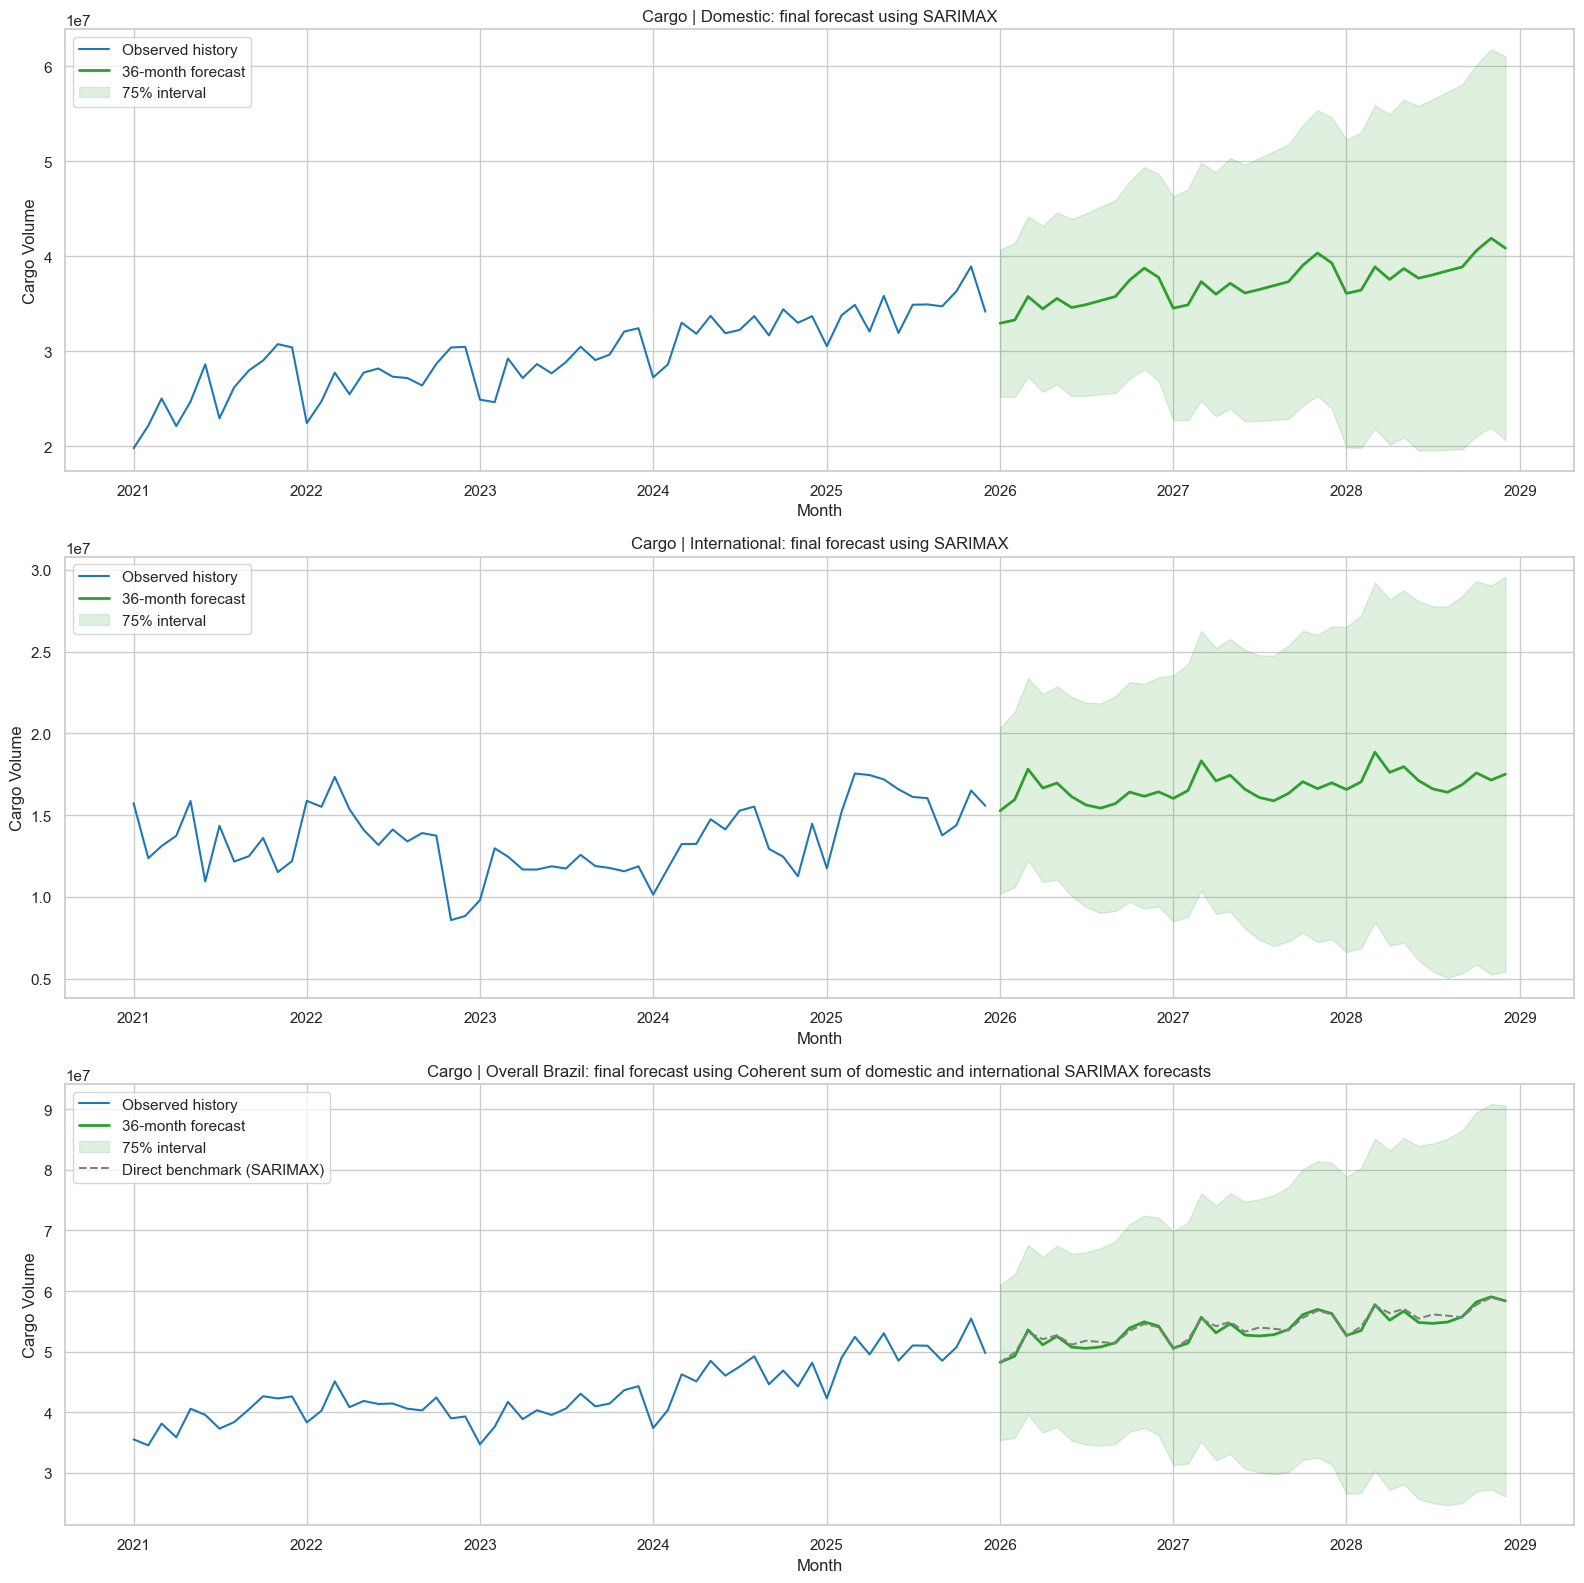

,year_month,forecast_value,lower_75,upper_75,target,series,model
0,2026-01-01,"9,112,288.13","7,066,388.37","11,158,187.88",Passenger,Domestic,SARIMAX
1,2026-02-01,"8,393,673.02","6,168,555.90","10,618,790.13",Passenger,Domestic,SARIMAX
2,2026-03-01,"8,303,301.73","5,937,436.08","10,669,167.39",Passenger,Domestic,SARIMAX
3,2026-04-01,"8,243,152.95","5,745,837.71","10,740,468.18",Passenger,Domestic,SARIMAX
4,2026-05-01,"8,128,790.84","5,506,687.04","10,750,894.64",Passenger,Domestic,SARIMAX
5,2026-06-01,"8,126,166.91","5,384,954.05","10,867,379.77",Passenger,Domestic,SARIMAX
6,2026-07-01,"8,806,154.19","5,950,796.76","11,661,511.61",Passenger,Domestic,SARIMAX
7,2026-08-01,"8,671,577.21","5,706,466.08","11,636,688.33",Passenger,Domestic,SARIMAX
8,2026-09-01,"8,663,417.90","5,592,473.10","11,734,362.70",Passenger,Domestic,SARIMAX
9,2026-10-01,"9,074,962.77","5,901,712.08","12,248,213.46",Passenger,Domestic,SARIMAX


In [9]:
forecast_tables = []

for target_name, series_dict in datasets.items():
    fig, axes = plt.subplots(3, 1, figsize=(16, 16))

    for ax, series_name in zip(axes, SERIES_ORDER):
        frame = series_dict[series_name]
        output = final_outputs[target_name][series_name]
        forecast_df = output['forecast_df']
        recent_history = frame.tail(60)

        ax.plot(recent_history['year_month'], recent_history['value'], label='Observed history', color='tab:blue')
        ax.plot(forecast_df['year_month'], forecast_df['forecast_value'], label='36-month forecast', color='tab:green', linewidth=2)
        ax.fill_between(
            forecast_df['year_month'],
            forecast_df['lower_75'],
            forecast_df['upper_75'],
            color='tab:green',
            alpha=0.15,
            label='75% interval'
        )

        if series_name == 'Overall Brazil':
            direct_df = direct_overall_outputs[target_name]['forecast_df']
            ax.plot(
                direct_df['year_month'],
                direct_df['forecast_value'],
                label=f"Direct benchmark ({direct_overall_outputs[target_name]['model_name']})",
                color='gray',
                linestyle='--'
            )

        ax.set_title(f"{target_name} | {series_name}: final forecast using {output['model_name']}")
        ax.set_xlabel('Month')
        ax.set_ylabel(TARGET_CONFIGS[target_name]['unit_label'].title())
        ax.legend()

        table = forecast_df.copy()
        table['target'] = target_name
        table['series'] = series_name
        table['model'] = output['model_name']
        forecast_tables.append(table)

    plt.tight_layout()
    plt.show()

all_forecasts = pd.concat(forecast_tables, ignore_index=True)
display(all_forecasts.head(18))

In [11]:
business_summary = []
for target_name, series_dict in datasets.items():
    for series_name, frame in series_dict.items():
        forecast_df = final_outputs[target_name][series_name]['forecast_df']
        last_actual = frame['value'].iloc[-1]
        first_year_avg = forecast_df.head(12)['forecast_value'].mean()
        third_year_avg = forecast_df.tail(12)['forecast_value'].mean()
        business_summary.append({
            'target': target_name,
            'series': series_name,
            'selected_model': final_outputs[target_name][series_name]['model_name'],
            'last_actual_month': frame['year_month'].iloc[-1].date(),
            'last_actual_value': last_actual,
            'avg_forecast_year_1': first_year_avg,
            'avg_forecast_year_3': third_year_avg,
        })

business_summary_df = pd.DataFrame(business_summary)
display(business_summary_df.round(2))

,target,series,selected_model,last_actual_month,last_actual_value,avg_forecast_year_1,avg_forecast_year_3
0,Passenger,Domestic,SARIMAX,2025-12-01,"8,729,241.00","8,656,576.01","9,421,454.94"
1,Passenger,International,SARIMAX,2025-12-01,"788,063.00","815,369.60","935,535.84"
2,Passenger,Overall Brazil,Coherent sum of domestic and international SAR...,2025-12-01,"9,517,304.00","9,471,945.60","10,356,990.78"
3,Cargo,Domestic,SARIMAX,2025-12-01,"34,188,162.00","35,573,335.82","38,695,853.70"
4,Cargo,International,SARIMAX,2025-12-01,"15,571,789.00","16,208,805.76","17,268,726.39"
5,Cargo,Overall Brazil,Coherent sum of domestic and international SAR...,2025-12-01,"49,759,951.00","51,782,141.58","55,964,580.09"


## Model Assessment Summary

The comparison tables and charts above should be used together.

- If the selected model beats the seasonal naive baseline by a meaningful margin, it is adding forecasting value.
- If MAPE stays below the 20% business threshold, the result satisfies the project target for the tested period.
- If the error plots still show large residual structure, the selected model can be improved later with more tuning or external regressors.

The final output of this notebook is a set of forecast tables and plots for domestic, international, and overall Brazil traffic for both passenger and cargo targets.